# Assignment: Systematischer Modellvergleich – Mehrklassen-Klassifikation
## Gruppe C (Gruppe 3) · Datensatz „Fetal Health Classification“

**Kurs:** Maschinelles Lernen mit Python, scikit-learn und Keras · DHBW Stuttgart · SS 2026

| | |
|---|---|
| **Datensatz** | Fetal Health Classification (CTG-basierte Einstufung des fetalen Zustands) |
| **Quelle** | Kaggle: `andrewmvd/fetal-health-classification` (lokale Kopie: `fetal_health.csv`) |
| **Umfang** | 2.126 Samples · 21 Features (alle numerisch) |
| **Zielvariable** | `fetal_health`: 1 = Normal, 2 = Suspect, 3 = Pathological |
| **Besonderheit** | Stark imbalanciert (ca. 78 / 14 / 8 %) – Accuracy allein ist trügerisch, entscheidend ist v. a. der Recall der Klasse *Pathological* |

**Hinweis zur KI-Nutzung:** Gemäß den Regeln des Assignments sind KI-generierte Codeblöcke mit
`# Quelle: Claude` gekennzeichnet. Alle Interpretationen und Entscheidungsbegründungen müssen von der
Gruppe nachvollzogen, geprüft und in eigenen Worten vertreten werden können.
Alle Projektentscheidungen sind zusätzlich in der `ADR.md` dokumentiert.

## Fachlicher Kontext: Kardiotokographie (CTG)

Ein **Kardiotokogramm (CTG)** zeichnet während der Schwangerschaft die fetale Herzfrequenz (FHR)
und die Wehentätigkeit auf. Aus dem Signal werden die 21 Features dieses Datensatzes abgeleitet:

- **Baseline-Herzfrequenz** (`baseline value`, Schläge/Minute)
- **Akzelerationen** (`accelerations`) – kurzfristige FHR-Anstiege; ihr Vorhandensein gilt als Zeichen fetalen Wohlbefindens
- **Dezelerationen** (`light_/severe_/prolongued_decelerations`) – FHR-Abfälle; je nach Typ ein Warnzeichen
- **Kurz- und Langzeit-Variabilität** (`…short_term_variability`, `…long_term_variability`) – eine eingeschränkte bzw. abnorme Variabilität ist ein bekannter Risikomarker
- **Histogramm-Kennwerte** (`histogram_…`) – statistische Beschreibung der FHR-Werteverteilung über die gesamte Aufzeichnung (Breite, Modus, Mittelwert, Varianz, …)

Die Zielvariable `fetal_health` wurde von Geburtsmedizinern vergeben:
**1 = Normal**, **2 = Suspect (verdächtig)**, **3 = Pathological (pathologisch)**.

**Praxisrelevanz:** Ein Modell auf diesen Daten wäre ein Screening-/Assistenzsystem.
Die teuerste Fehlklassifikation ist ein **übersehener pathologischer Fall (falsch-negativ)** –
deshalb betrachten wir im gesamten Assignment neben Accuracy und F1 (weighted) insbesondere den
**Recall der Klasse Pathological**.

---
# Schritt 1 – Datenanalyse

Laut Assignment umfasst Schritt 1:

1. Datensatz laden; Form, Datentypen und fehlende Werte überblicken
2. Verteilung der Zielvariable über alle Klassen dokumentieren (absolut und prozentual)
3. Mindestens 3 aussagekräftige Visualisierungen:
   - Verteilung numerischer Features (Histogramme)
   - Balkendiagramm der Klassenverteilung der Zielvariable
   - Korrelationsmatrix der numerischen Features
   - Zusammenhang zwischen Features und Zielklassen
4. Einschätzung mit Begründung: Welche Features erscheinen besonders relevant?

## 1.1 Setup und Daten laden

Wir laden die im Kurs verwendeten Bibliotheken (`pandas`, `numpy`, `matplotlib`, `seaborn`) und
definieren eine **feste Farbzuordnung** für die drei Zielklassen in Ampel-Logik
(grün = Normal, gelb = Suspect, rot = Pathological). Die Klassennamen stehen immer zusätzlich
als Text an den Achsen – Farbe ist nie alleiniger Bedeutungsträger.

In [1]:
# Quelle: Claude
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42  # Reproduzierbarkeit (wird ab Schritt 2 für Splits/Modelle verwendet)

# Einheitlicher, dezenter Plot-Stil: zurückhaltende Gitterlinien, klare Beschriftung
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "grid.color": "#e1e0d9",
    "axes.edgecolor": "#c3c2b7",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})

# Klassen-Labels und feste Statusfarben (Ampel-Logik im medizinischen Kontext)
CLASS_NAMES = {1.0: "Normal", 2.0: "Suspect", 3.0: "Pathological"}
CLASS_ORDER = ["Normal", "Suspect", "Pathological"]
CLASS_COLORS = {"Normal": "#0ca30c", "Suspect": "#fab219", "Pathological": "#d03b3b"}

df = pd.read_csv("fetal_health.csv")
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


## 1.2 Form, Datentypen und Datenqualität

Erster Überblick: Wie groß ist der Datensatz, welche Datentypen liegen vor,
gibt es fehlende Werte oder Duplikate?

In [2]:
# Quelle: Claude
print("Form (Zeilen, Spalten):", df.shape)
print()
df.info()
print()
print("Fehlende Werte gesamt:", df.isna().sum().sum())
print("Exakte Duplikat-Zeilen:", df.duplicated().sum())

Form (Zeilen, Spalten): (2126, 22)

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of

### Beobachtungen zu Form und Datenqualität

- Der Datensatz enthält **2.126 Samples** und **22 Spalten** (21 Features + Zielvariable
  `fetal_health`) – das entspricht exakt der Angabe im Assignment.
- **Alle Spalten sind numerisch** (`float64`). Es gibt **keine kategorischen Text-Features**,
  eine Feature-Kodierung (One-Hot / Label Encoding) entfällt damit in Schritt 2.
  Die Zielvariable liegt bereits numerisch kodiert vor (1 / 2 / 3).
- Es gibt **keine fehlenden Werte** (0 von 2.126 × 22 Zellen) – eine Imputation ist nicht
  erforderlich (→ ADR-003).
- Es existieren **13 exakte Duplikat-Zeilen** (≈ 0,6 %). **Entscheidung (→ ADR-004):**
  Die Duplikate werden in Schritt 2 *vor* dem Train/Validation/Test-Split entfernt.
  Begründung: Identische Zeilen könnten sonst gleichzeitig im Trainings- **und** im
  Validierungs-/Test-Set landen – die gemessene Generalisierungsleistung würde dadurch
  künstlich (leakage-artig) überschätzt. In Schritt 1 (rein deskriptiv) bleiben sie zunächst
  im Datensatz, da 13 von 2.126 Zeilen die Statistiken praktisch nicht verändern.

## 1.3 Statistische Kennzahlen

`describe()` liefert Lage- und Streuungsmaße aller Features – wichtig, um Wertebereiche,
Skalenunterschiede und mögliche Ausreißer zu erkennen.

In [3]:
# Quelle: Claude
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.304,9.841,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003,0.004,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009,0.047,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004,0.003,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.002,0.003,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000,0.000,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000,0.001,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990,17.193,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.333,0.883,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.847,18.397,0.0,0.000,0.000,11.000,91.000


### Beobachtungen zu den Kennzahlen

- Die Features liegen auf **sehr unterschiedlichen Skalen**: `baseline value` bewegt sich
  zwischen 106 und 160 (Schläge/Minute), `accelerations` dagegen zwischen 0 und ~0,02
  (Ereignisse pro Sekunde), `histogram_variance` zwischen 0 und 269.
  → Für skalensensitive Modelle (Logistische Regression, k-NN/SVM, neuronale Netze) ist eine
  **Skalierung in Schritt 2 zwingend**; Baumverfahren sind davon unabhängig.
- Mehrere Features sind **stark nullenlastig**: `severe_decelerations` ist in ≈ 99,7 % der
  Zeilen 0, `prolongued_decelerations` in ≈ 92 %, auch `fetal_movement` und
  `light_decelerations` bestehen mehrheitlich aus Nullen. Solche seltenen Ereignisse können
  trotzdem hoch informativ sein (siehe 1.6/1.7).
- Die Wertebereiche sind **physiologisch plausibel** (z. B. FHR-Baseline 106–160 bpm);
  es gibt keine offensichtlich fehlerhaften Werte (keine negativen Häufigkeiten o. Ä.),
  daher entfernen wir keine „Ausreißer“ – bei CTG-Daten sind Extremwerte gerade die
  diagnostisch interessanten Fälle.

## 1.4 Verteilung der Zielvariable

Da der Datensatz außer der Zielvariable keine kategorialen Größen enthält, ist das folgende
Balkendiagramm zugleich die im Assignment geforderte Balkendiagramm-Visualisierung
(„Kategorische Features inkl. Klassenverteilung der Zielvariable“).

,Klasse,Anzahl,Anteil (%)
Code,,,
1,Normal,1655,77.85
2,Suspect,295,13.88
3,Pathological,176,8.28


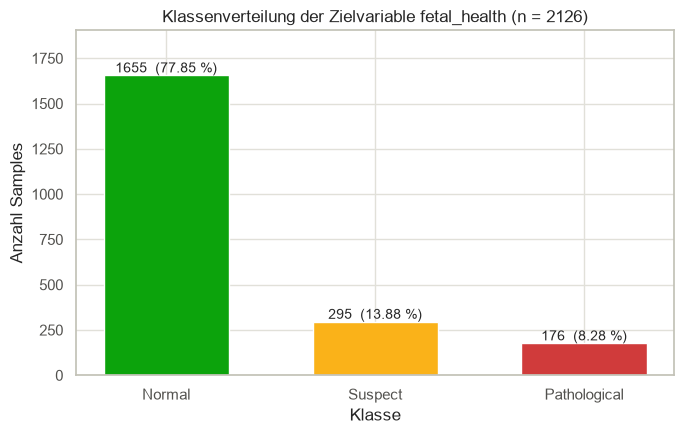

In [4]:
# Quelle: Claude
counts = df["fetal_health"].value_counts().sort_index()
dist = pd.DataFrame({
    "Klasse": [CLASS_NAMES[c] for c in counts.index],
    "Anzahl": counts.values,
    "Anteil (%)": (counts.values / len(df) * 100).round(2),
}, index=counts.index.astype(int))
dist.index.name = "Code"
display(dist)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(dist["Klasse"], dist["Anzahl"],
              color=[CLASS_COLORS[k] for k in dist["Klasse"]], width=0.6)
for bar, n, p in zip(bars, dist["Anzahl"], dist["Anteil (%)"]):
    ax.annotate(f"{n}  ({p} %)",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)
ax.set_title("Klassenverteilung der Zielvariable fetal_health (n = 2126)")
ax.set_xlabel("Klasse")
ax.set_ylabel("Anzahl Samples")
ax.set_ylim(0, dist["Anzahl"].max() * 1.15)
plt.tight_layout()
plt.show()

### Beobachtungen zur Klassenverteilung – wie ausgewogen sind die Klassen?

| Klasse | absolut | prozentual |
|---|---|---|
| 1 = Normal | 1.655 | 77,85 % |
| 2 = Suspect | 295 | 13,88 % |
| 3 = Pathological | 176 | 8,28 % |

Die Klassen sind **stark imbalanciert** (Verhältnis größte : kleinste Klasse ≈ 9,4 : 1).
Das deckt sich mit der Angabe im Assignment (ca. 78 / 14 / 8 %). Konsequenzen:

1. **Naive Baseline:** Ein Modell, das *immer* „Normal“ vorhersagt, erreicht bereits
   ≈ 77,9 % Accuracy – jede Modellbewertung muss sich an dieser Baseline messen lassen.
   Accuracy allein ist hier also trügerisch.
2. **Metriken:** Wir berichten durchgängig zusätzlich **F1 (weighted)** und je Klasse
   Precision/Recall (`classification_report`); besonders kritisch ist der
   **Recall der Klasse Pathological** (übersehene Pathologien sind im Praxiskontext am teuersten).
3. **Splits:** Train/Validation/Test-Split und Kreuzvalidierung erfolgen **stratifiziert**,
   damit die kleinen Klassen (v. a. Pathological mit nur 176 Fällen) in jeder Teilmenge
   im gleichen Verhältnis vertreten sind.
4. **Modellbildung:** Ggf. `class_weight="balanced"` bzw. Klassengewichte als begründeter
   Freiheitsgrad in Schritt 3/6.

## 1.5 Visualisierung 1 – Verteilung der numerischen Features (Histogramme)

Histogramme aller 21 Features geben einen Überblick über Verteilungsformen
(symmetrisch vs. schief), Wertebereiche und Besonderheiten.

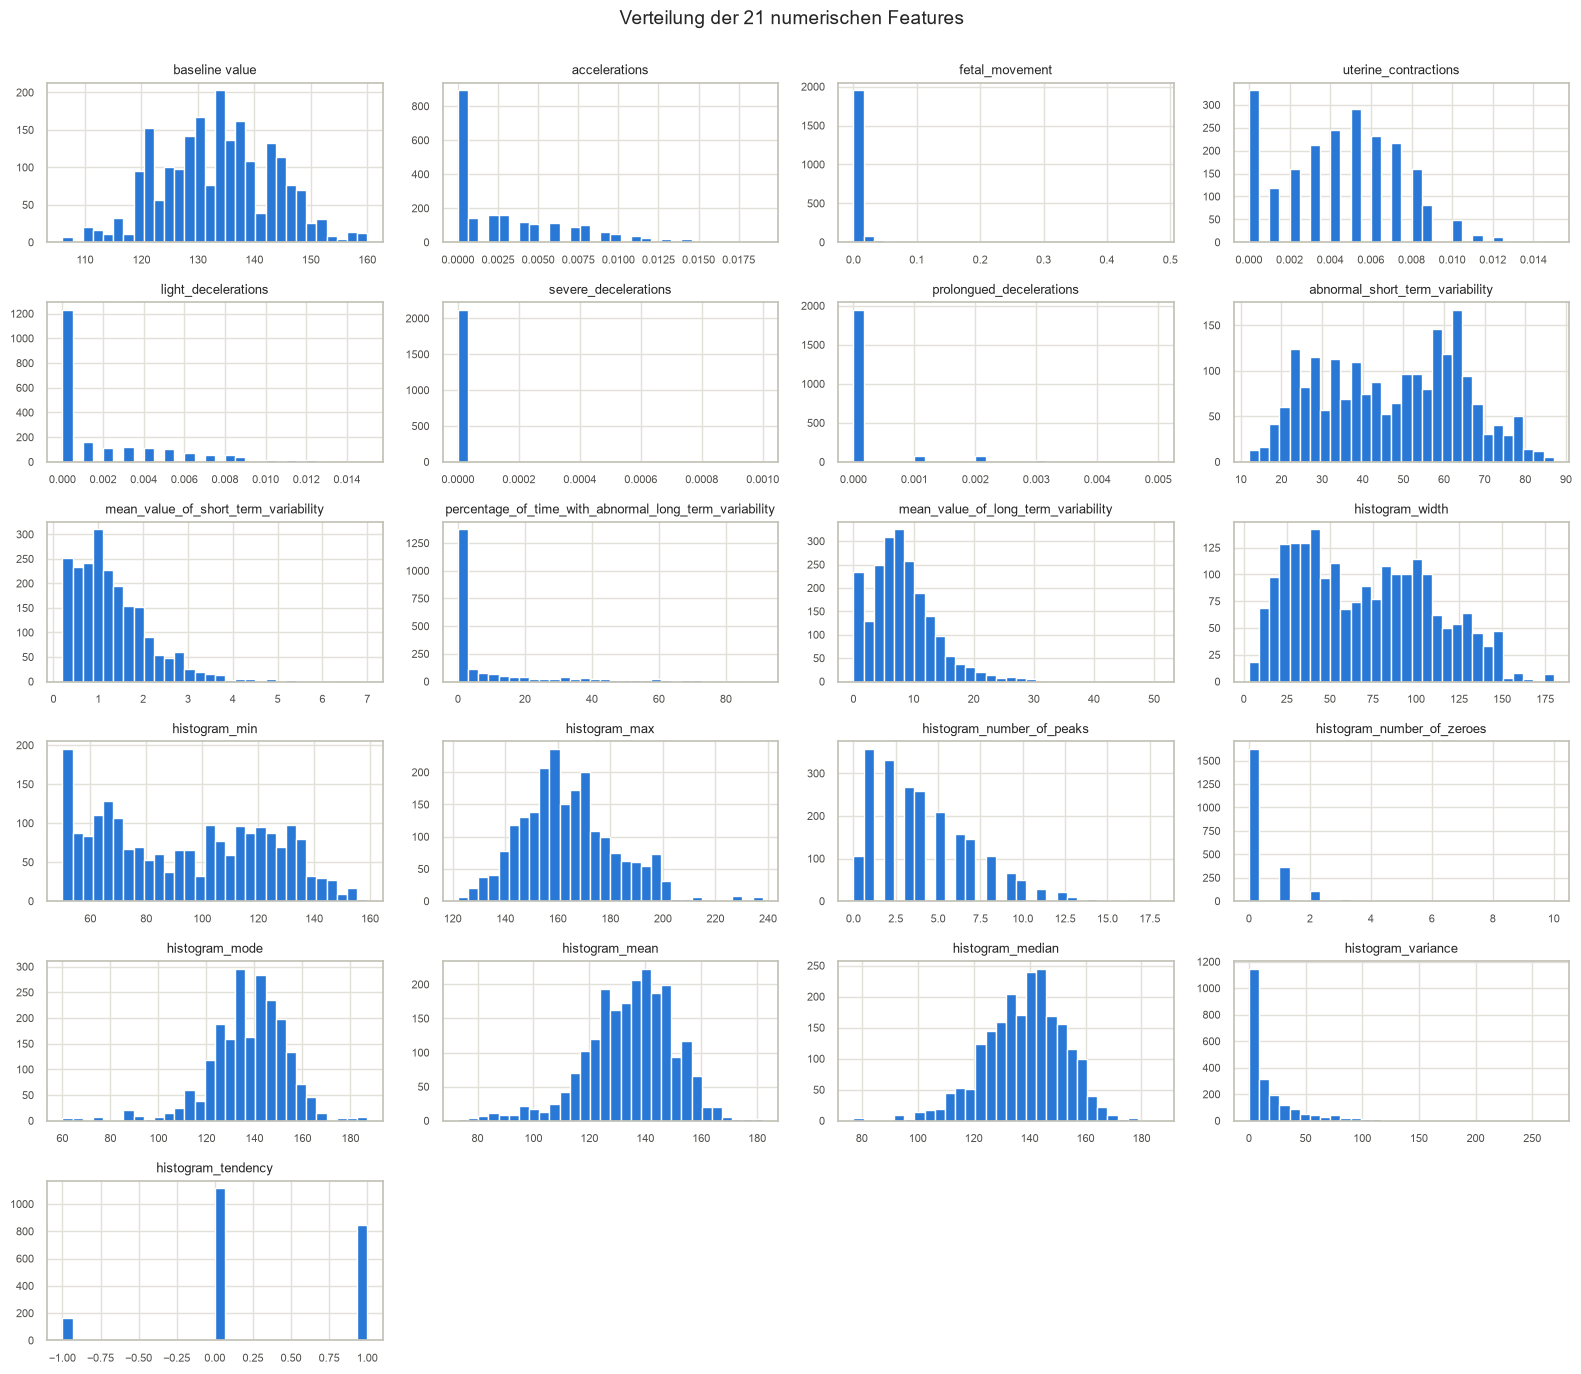

In [5]:
# Quelle: Claude
features = df.drop(columns="fetal_health")

axes = features.hist(bins=30, figsize=(16, 14), layout=(6, 4),
                     color="#2a78d6", edgecolor="white", grid=True)
for ax in axes.ravel():
    ax.set_title(ax.get_title(), fontsize=9)
    ax.tick_params(labelsize=8)
fig = plt.gcf()
fig.suptitle("Verteilung der 21 numerischen Features", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

### Beobachtungen zu den Feature-Verteilungen

- **Annähernd symmetrisch / glockenförmig:** `baseline value`, `histogram_mode`,
  `histogram_mean`, `histogram_median` – klassische Lageparameter der Herzfrequenz.
- **Stark rechtsschief bzw. nullen-dominiert:** `fetal_movement`, `light_decelerations`,
  `severe_decelerations`, `prolongued_decelerations`, `histogram_variance`,
  `percentage_of_time_with_abnormal_long_term_variability` – seltene Ereignisse,
  die nur bei einem Teil der CTGs auftreten.
- **Faktisch ordinal, obwohl als `float64` gespeichert:** `histogram_tendency` nimmt nur die
  drei Werte −1 / 0 / 1 an (Tendenz des FHR-Histogramms: links-/symmetrisch/rechtsschief),
  `histogram_number_of_zeroes` nur kleine ganze Zahlen. Da die Werte bereits numerisch und
  sinnvoll geordnet sind, ist **keine One-Hot-Kodierung nötig** – wir behandeln sie als
  numerische Features (→ ADR-006).
- `severe_decelerations` ist **quasi-konstant** (nur 7 von 2.126 Zeilen ≠ 0). Das Feature
  trägt für die meisten Modelle kaum Information, wir behalten es aber zunächst bei, da
  Baumverfahren und regularisierte Modelle damit umgehen können und der klinische
  Informationsgehalt im Einzelfall hoch ist (schwere Dezelerationen = akutes Warnzeichen).
- Die sehr **unterschiedlichen Größenordnungen** (z. B. `accelerations` ≈ 10⁻³ vs.
  `histogram_max` ≈ 10²) bestätigen die Notwendigkeit der **Standardisierung** in Schritt 2.

## 1.6 Visualisierung 2 – Korrelationsmatrix der numerischen Features

Die Korrelationsmatrix (Pearson) zeigt lineare Zusammenhänge **zwischen den Features**
(Multikollinearität) sowie erste Hinweise auf den Zusammenhang mit der Zielvariable.
Wir blenden die redundante obere Dreieckshälfte aus.

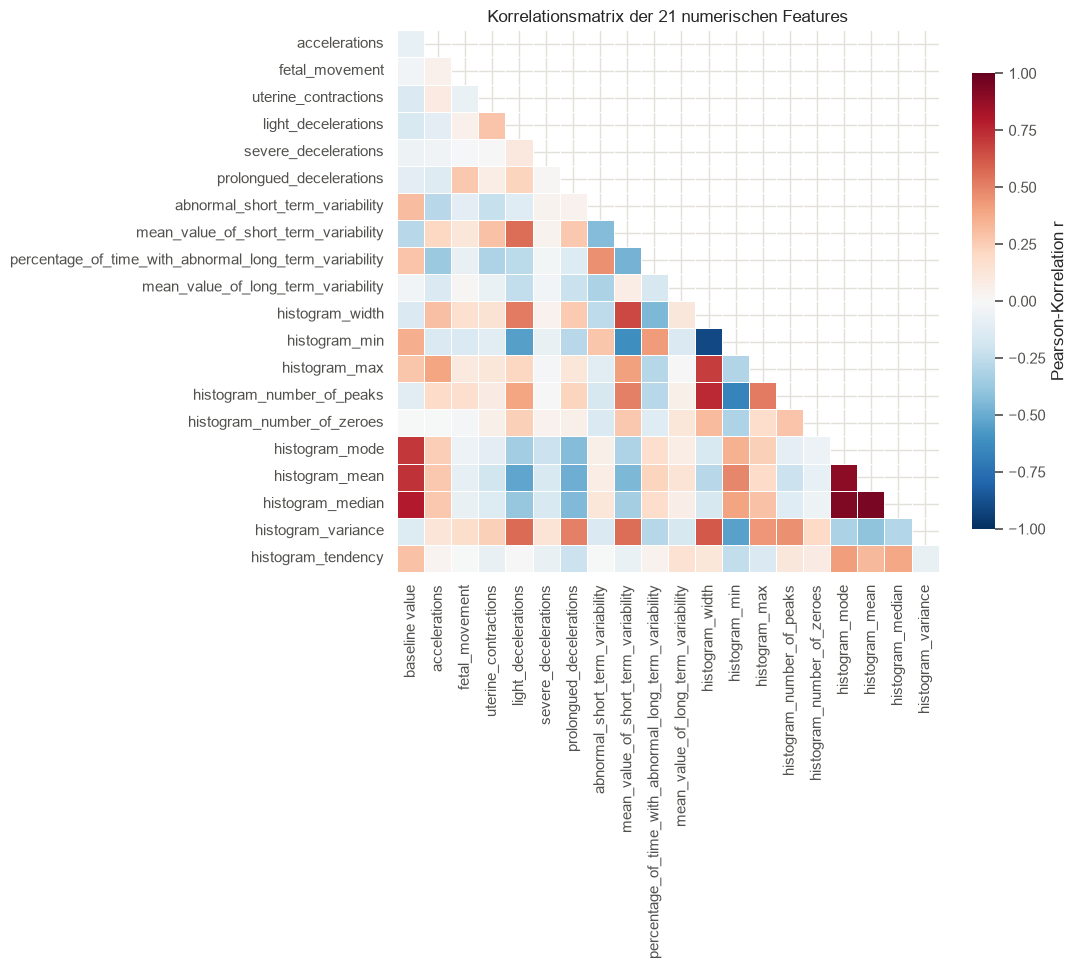

Feature-Paare mit |r| >= 0.8:


,,r
histogram_mean,histogram_median,0.948
histogram_mode,histogram_median,0.933
histogram_width,histogram_min,-0.899
histogram_mode,histogram_mean,0.893


In [6]:
# Quelle: Claude
corr = features.corr()

# Nur die untere Dreieckshälfte zeigen: die obere ist spiegelbildlich redundant,
# die Diagonale ist konstant 1. Erste Zeile / letzte Spalte wären danach leer -> abschneiden.
corr_lower = corr.iloc[1:, :-1]
mask = np.triu(np.ones_like(corr_lower, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 11))
sns.heatmap(corr_lower, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Pearson-Korrelation r", "shrink": 0.6}, ax=ax)
ax.set_title("Korrelationsmatrix der 21 numerischen Features")
plt.tight_layout()
plt.show()

# Feature-Paare mit sehr starkem linearem Zusammenhang (Multikollinearität)
strong = (corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1).astype(bool))
              .stack()
              .loc[lambda s: s.abs() >= 0.8]
              .sort_values(key=abs, ascending=False))
print("Feature-Paare mit |r| >= 0.8:")
display(strong.round(3).to_frame("r"))

Zusätzlich betrachten wir gezielt die Korrelation jedes Features **mit der Zielvariable**.
`fetal_health` ist ordinal (1 < 2 < 3), Pearson-Korrelation ist hier also nur eine
**Heuristik zur Vorauswahl** – nicht-monotone Zusammenhänge unterschätzt sie systematisch
(siehe 1.7). Die exakten Werte stehen in der Tabelle, das Diagramm zeigt das Ranking.

,r zu fetal_health
prolongued_decelerations,0.485
abnormal_short_term_variability,0.471
percentage_of_time_with_abnormal_long_term_variability,0.426
accelerations,-0.364
histogram_mode,-0.250
histogram_mean,-0.227
mean_value_of_long_term_variability,-0.227
histogram_variance,0.207
histogram_median,-0.205
uterine_contractions,-0.205


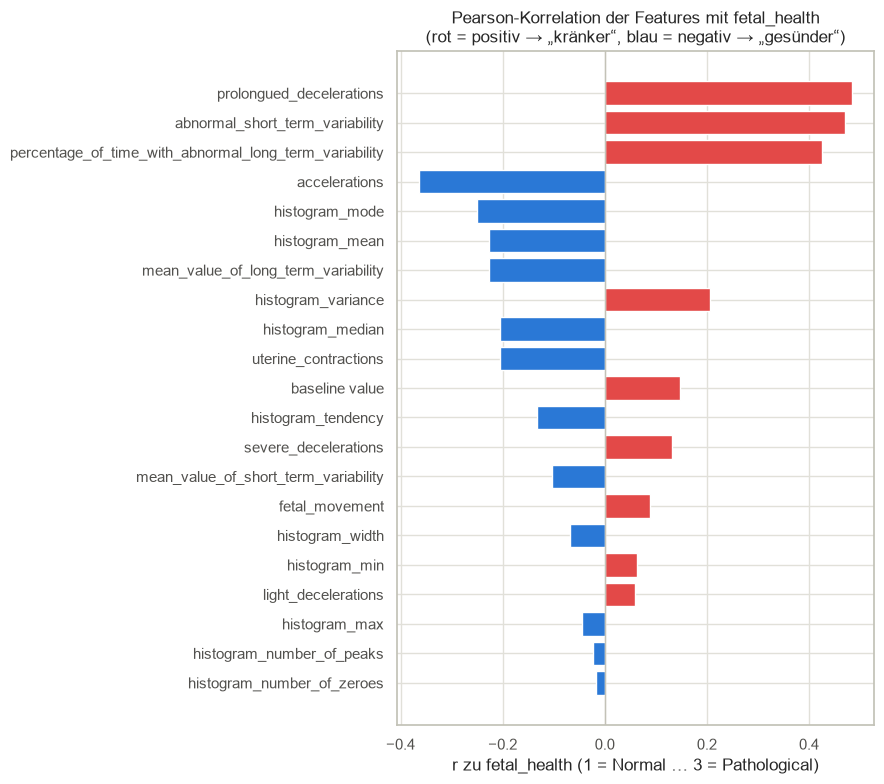

In [7]:
# Quelle: Claude
target_corr = df.corr()["fetal_health"].drop("fetal_health")
ranking = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
display(ranking.round(3).to_frame("r zu fetal_health"))

plot_order = ranking.iloc[::-1]  # barh zeichnet von unten nach oben -> umdrehen, damit |r| oben am größten ist
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#e34948" if v > 0 else "#2a78d6" for v in plot_order]
ax.barh(plot_order.index, plot_order.values, color=colors)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_title("Pearson-Korrelation der Features mit fetal_health\n"
             "(rot = positiv → „kränker“, blau = negativ → „gesünder“)")
ax.set_xlabel("r zu fetal_health (1 = Normal … 3 = Pathological)")
plt.tight_layout()
plt.show()

### Beobachtungen zu den Korrelationen

**Zusammenhang mit der Zielvariable (Top-Features nach |r|):**

- `prolongued_decelerations` (**+0,49**), `abnormal_short_term_variability` (**+0,47**) und
  `percentage_of_time_with_abnormal_long_term_variability` (**+0,43**) steigen mit dem
  Schweregrad – klinisch plausibel: verlängerte Dezelerationen und abnorme Variabilität
  sind bekannte Warnzeichen.
- `accelerations` (**−0,36**) sinkt mit dem Schweregrad – das *Fehlen* von Akzelerationen
  ist ein Risikomarker.
- Danach folgen die Histogramm-Lageparameter (`histogram_mode` −0,25, `histogram_mean` −0,23,
  `histogram_median` −0,21) sowie `mean_value_of_long_term_variability` (−0,23),
  `histogram_variance` (+0,21) und `uterine_contractions` (−0,21).

**Multikollinearität zwischen Features:**

- `histogram_mode`, `histogram_mean` und `histogram_median` sind untereinander sehr stark
  korreliert (**r ≈ 0,89–0,95**) – sie messen fast dasselbe (Lage der FHR-Verteilung).
- `histogram_width` und `histogram_min` korrelieren mit **r ≈ −0,90** (breites Histogramm ⇔
  niedriges Minimum).
- **Konsequenz:** Für die Logistische Regression sind dadurch einzelne Koeffizienten schwer
  interpretierbar (instabil); die Vorhersagegüte leidet i. d. R. wenig. Baumverfahren sind
  gegenüber Multikollinearität robust. Wir entfernen daher **keine** Features vorab, merken
  die Redundanz aber als möglichen Vereinfachungshebel für Schritt 6/7 vor (→ ADR-005).

## 1.7 Visualisierung 3 – Zusammenhang zwischen Features und Zielklassen

Boxplots der acht Features mit der höchsten |Korrelation| zur Zielvariable, getrennt nach
Klasse. Sie zeigen auch **nicht-monotone** Muster, die die Pearson-Korrelation verdeckt.

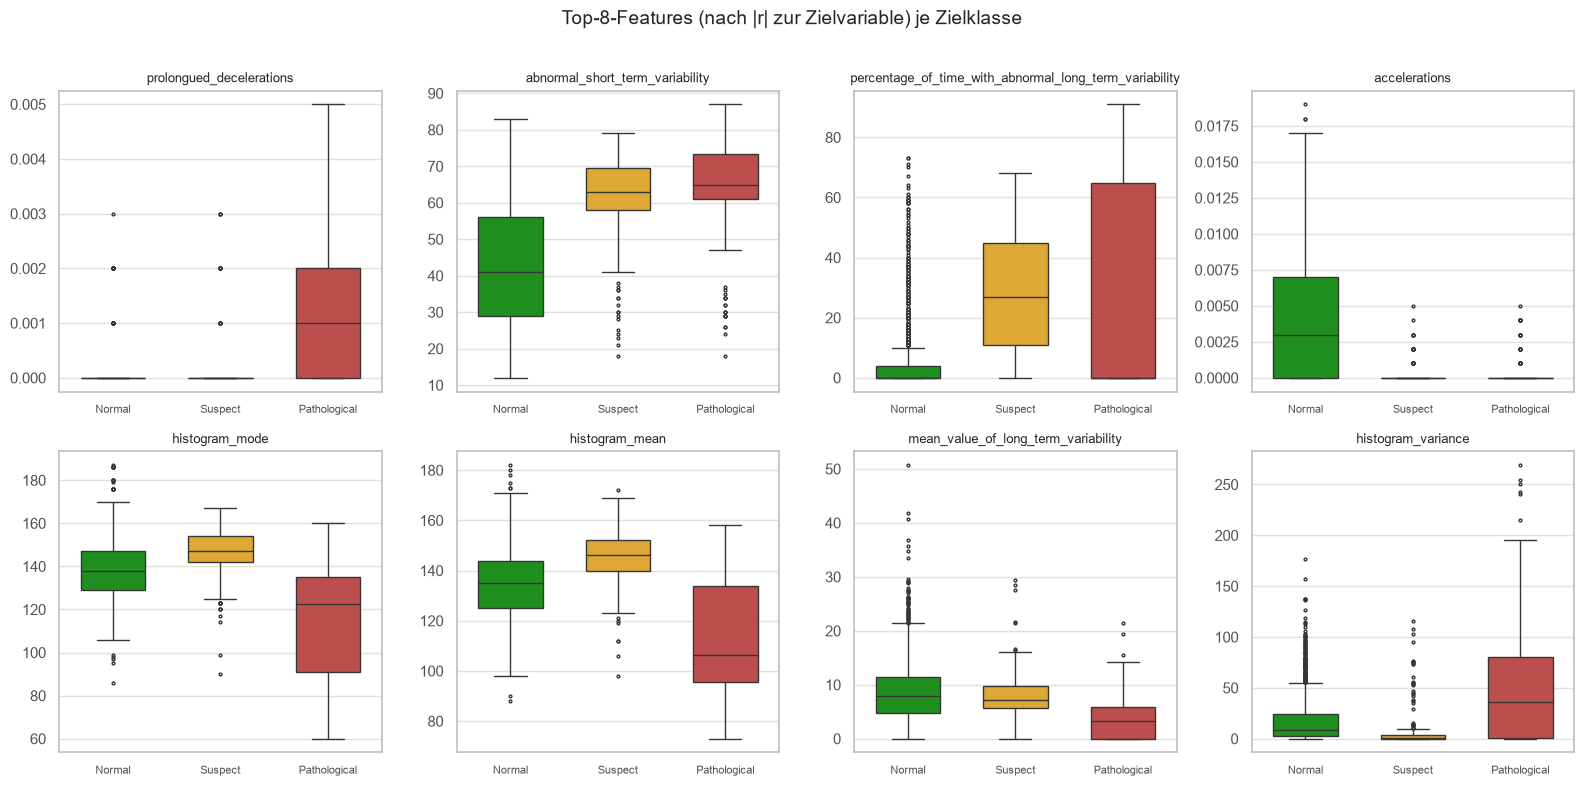

In [8]:
# Quelle: Claude
top_features = target_corr.abs().sort_values(ascending=False).head(8).index.tolist()

df_plot = df.copy()
df_plot["Klasse"] = df_plot["fetal_health"].map(CLASS_NAMES)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat in zip(axes.ravel(), top_features):
    sns.boxplot(data=df_plot, x="Klasse", y=feat, order=CLASS_ORDER,
                hue="Klasse", hue_order=CLASS_ORDER, palette=CLASS_COLORS,
                legend=False, width=0.6, fliersize=2, ax=ax)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")  # Feature-Name steht bereits im Titel -> lange Labels weglassen
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Top-8-Features (nach |r| zur Zielvariable) je Zielklasse", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

In [9]:
# Quelle: Claude
# Mediane der Top-8-Features je Klasse (Zahlenbasis für die Interpretation)
medians = df_plot.groupby("Klasse")[top_features].median().reindex(CLASS_ORDER)
medians.T.round(4)

Klasse,Normal,Suspect,Pathological
prolongued_decelerations,0.000,0.0,0.001
abnormal_short_term_variability,41.000,63.0,65.000
percentage_of_time_with_abnormal_long_term_variability,0.000,27.0,0.000
accelerations,0.003,0.0,0.000
histogram_mode,138.000,147.0,122.500
histogram_mean,135.000,146.0,106.500
mean_value_of_long_term_variability,8.000,7.1,3.250
histogram_variance,9.000,1.0,36.500


### Beobachtungen zum Feature-Klassen-Zusammenhang

- **`abnormal_short_term_variability`** trennt am klarsten: Median 41 (Normal) → 63 (Suspect)
  → 65 (Pathological).
- **`accelerations`**: Normale CTGs zeigen Akzelerationen (Median 0,003/s), Suspect- und
  Pathological-CTGs praktisch keine (Median 0) – das Fehlen ist das Warnzeichen.
- **`prolongued_decelerations`** treten fast ausschließlich bei Pathological auf
  (Median 0,001/s vs. 0 bei beiden anderen Klassen) – selten, aber hochspezifisch.
- **`percentage_of_time_with_abnormal_long_term_variability`** ist v. a. bei **Suspect**
  erhöht (Median 27 vs. 0); bei Pathological ist die Verteilung zweigeteilt
  (Median 0, Mittelwert ≈ 23) – ein Teil der pathologischen CTGs zeigt dieses Muster stark,
  ein Teil gar nicht.
- **Nicht-monoton** (und darum von Pearson unterschätzt): `histogram_mean`/`histogram_mode`
  liegen bei Suspect *höher* als bei Normal (≈ 146/147 vs. 135/138), bei Pathological dagegen
  deutlich *niedriger* (≈ 106/122 – Tendenz zur Bradykardie). Ebenso `histogram_variance`:
  Suspect am niedrigsten (Median 1), Pathological am höchsten (Median 36,5).
  → Solche U-förmigen Zusammenhänge sprechen dafür, dass **nichtlineare Modelle**
  (Baumverfahren, Netze) hier Vorteile gegenüber der Logistischen Regression haben könnten.
- **`mean_value_of_long_term_variability`** ist bei Pathological deutlich reduziert
  (Median 3,25 vs. 8,0 bei Normal) – eingeschränkte Variabilität als Risikomarker.

## 1.8 Fazit Schritt 1: Welche Features erscheinen besonders relevant?

**Als besonders relevant schätzen wir ein** (Begründung: hohe |Korrelation| zur Zielvariable
**und** klare Klassentrennung in den Boxplots **und** klinische Plausibilität):

1. `abnormal_short_term_variability` – stärkste, nahezu monotone Trennung aller drei Klassen
2. `prolongued_decelerations` – hochspezifisch für Pathological
3. `percentage_of_time_with_abnormal_long_term_variability` – markiert v. a. Suspect
4. `accelerations` – Fehlen von Akzelerationen als Risikomarker (negativer Zusammenhang)
5. `histogram_mean` / `histogram_mode` / `histogram_median` – trennen Pathological über die
   Bradykardie-Tendenz, allerdings nicht-monoton und untereinander redundant (r ≈ 0,9)
6. `mean_value_of_long_term_variability` und `histogram_variance` – ergänzende
   Variabilitätsmarker

Diese Einschätzung ist eine **EDA-Hypothese**; verlässliche Aussagen über Feature-Wichtigkeit
liefern erst die Modelle (z. B. Feature Importances des Baumverfahrens in Schritt 3/6).

**Konsequenzen für die nächsten Schritte:**

- Schritt 2: 13 Duplikate entfernen (vor dem Split) · keine Imputation nötig · keine
  Feature-Kodierung nötig · Zielvariable mit `LabelEncoder` auf 0/1/2 mappen ·
  **stratifizierter** 70/15/15-Split · `StandardScaler` **nur auf den Trainingsdaten fitten**
- Schritt 3 ff.: Bewertung primär über F1 (weighted) und `classification_report`,
  besonderes Augenmerk auf den **Recall der Klasse Pathological**; Accuracy immer gegen die
  77,9-%-Baseline („immer Normal“) einordnen
- Nicht-monotone Zusammenhänge (1.7) → nichtlineare Modelle könnten im Vorteil sein

---
# Schritt 2 – Preprocessing und Datenvorbereitung

Laut Assignment umfasst Schritt 2:

1. Fehlende Werte identifizieren, behandeln und Entscheidung begründen
2. Kategorische Features kodieren (One-Hot oder Label Encoding – mit Begründung)
3. Zielvariable mit `LabelEncoder` in Integer-Codes umwandeln und das Mapping dokumentieren
4. Stratifizierten Train/Validation/Test-Split (70 / 15 / 15) durchführen
5. Features skalieren – welche und warum?
6. Frage beantworten: Darf der Scaler auf dem gesamten Datensatz gefittet werden?

Zusätzlich setzen wir hier die in Schritt 1 getroffene Entscheidung um, die
13 Duplikat-Zeilen **vor** dem Split zu entfernen (→ ADR-004).

## 2.1 Fehlende Werte identifizieren und behandeln

Die Prüfung aus Schritt 1.2 wird hier noch einmal explizit als Preprocessing-Schritt
ausgeführt, da das Assignment die Behandlung fehlender Werte in Schritt 2 verlangt.

In [10]:
# Quelle: Claude
fehlend = df.isna().sum()
print("Fehlende Werte gesamt:      ", fehlend.sum())
print("Spalten mit fehlenden Werten:", (fehlend > 0).sum(), "von", df.shape[1])

Fehlende Werte gesamt:       0
Spalten mit fehlenden Werten: 0 von 22


**Entscheidung (→ ADR-003): keine Imputation.**
Der Datensatz enthält in keiner der 2.126 × 22 Zellen einen fehlenden Wert – es gibt schlicht
nichts zu behandeln. Jede Imputationsstrategie (Mittelwert, Median, k-NN) würde nur
Komplexität und eine potenzielle Fehlerquelle einführen, ohne einen einzigen Wert zu ändern.
Die Prüfung bleibt bewusst als Codezelle im Notebook, um den geforderten Nachweis zu erbringen –
bei einem Datensatz-Update würde sie sofort anschlagen.

## 2.2 Duplikate entfernen – vor dem Split

Umsetzung der Entscheidung aus Schritt 1.2 (→ ADR-004): Identische Zeilen könnten durch den
zufälligen Split gleichzeitig im Trainings- **und** im Validierungs-/Testset landen. Das Modell
würde dann auf Daten bewertet, die es exakt so schon gesehen hat – die gemessene
Generalisierungsleistung wäre (leakage-artig) überschätzt. Deshalb muss das Entfernen
**vor** dem Split geschehen.

In [11]:
# Quelle: Claude
print("Zeilen vor dem Entfernen: ", len(df))
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Zeilen nach dem Entfernen:", len(df_clean),
      f"  ({len(df) - len(df_clean)} Duplikate entfernt)")

verteilung = df_clean["fetal_health"].value_counts().sort_index()
print("\nKlassenverteilung nach der Duplikat-Entfernung:")
print(pd.DataFrame({
    "Klasse": [CLASS_NAMES[c] for c in verteilung.index],
    "n": verteilung.values,
    "%": (verteilung.values / len(df_clean) * 100).round(2),
}).to_string(index=False))

Zeilen vor dem Entfernen:  2126
Zeilen nach dem Entfernen: 2113   (13 Duplikate entfernt)

Klassenverteilung nach der Duplikat-Entfernung:
      Klasse    n     %
      Normal 1646 77.90
     Suspect  292 13.82
Pathological  175  8.28


Es verbleiben **2.113 Zeilen**. Die Klassenverteilung ändert sich dadurch praktisch nicht
(77,90 / 13,82 / 8,28 % statt 77,85 / 13,88 / 8,28 %) – die Duplikate waren also nicht auf
eine Klasse konzentriert. Ab hier arbeiten wir ausschließlich mit `df_clean`.

## 2.3 Kategorische Features kodieren?

Das Assignment verlangt eine begründete Kodierungs-Entscheidung (One-Hot vs. Label Encoding).
Dazu prüfen wir Datentypen und Kardinalität (Anzahl unterschiedlicher Werte) der Features.

In [12]:
# Quelle: Claude
print("Datentypen im Datensatz:", df_clean.dtypes.unique().tolist())
print("\nFeatures mit den wenigsten unterschiedlichen Werten:")
print(df_clean.nunique().sort_values().head(6).to_string())
print("\nWerte von histogram_tendency:", sorted(df_clean["histogram_tendency"].unique()))

Datentypen im Datensatz: [dtype('float64')]

Features mit den wenigsten unterschiedlichen Werten:
severe_decelerations           2
fetal_health                   3
histogram_tendency             3
prolongued_decelerations       6
histogram_number_of_zeroes     9
uterine_contractions          16

Werte von histogram_tendency: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]


**Entscheidung (→ ADR-006): keine Feature-Kodierung.**

- Es gibt **keine Text-/String-Features** – alle 21 Features liegen als `float64` vor.
  Der klassische Anwendungsfall für One-Hot- oder Label-Encoding entfällt vollständig.
- Das einzige kategorial *wirkende* Feature ist `histogram_tendency` mit den drei Werten
  −1 / 0 / 1 (Tendenz des FHR-Histogramms: linksschief / symmetrisch / rechtsschief).
  Es ist **ordinal mit sinnvoller Ordnung** und bereits passend numerisch kodiert.
  Ein One-Hot-Encoding würde die Ordnungsinformation zerstören und ohne Not drei Spalten
  erzeugen – wir behalten die numerische Darstellung bei.
- `severe_decelerations` (2 Ausprägungen) und `histogram_number_of_zeroes` (9 Ausprägungen)
  sind echte Zähl-/Messgrößen mit sinnvollen numerischen Abständen – ebenfalls keine
  Kodierung nötig.

## 2.4 Zielvariable kodieren (`LabelEncoder`) und Mapping dokumentieren

Die Zielvariable liegt als 1.0 / 2.0 / 3.0 (`float64`) vor – es gibt keine Klassentexte.
Wir kodieren sie trotzdem wie im Assignment gefordert mit dem `LabelEncoder` auf die
Integer-Codes **0 / 1 / 2**, denn:

- scikit-learn und Keras erwarten **0-basierte** Integer-Klassen; insbesondere setzt die
  Verlustfunktion `sparse_categorical_crossentropy` (Schritt 4/5) Codes von 0 bis
  n_classes−1 voraus.
- Der gefittete Encoder macht das Mapping explizit und erlaubt später die Rückübersetzung
  der Vorhersagen (`inverse_transform`).

In [13]:
# Quelle: Claude
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df_clean["fetal_health"])
X = df_clean.drop(columns="fetal_health")

# Klassennamen in Code-Reihenfolge (0, 1, 2) - wird in allen folgenden Schritten verwendet
TARGET_NAMES = [CLASS_NAMES[c] for c in le.classes_]

mapping = pd.DataFrame({
    "Originalwert (fetal_health)": le.classes_,
    "Klasse": TARGET_NAMES,
}, index=pd.Index(range(len(le.classes_)), name="Code"))
display(mapping)

print("X:", X.shape, "| y:", y.shape, "| Klassen in y:", np.unique(y))

,Originalwert (fetal_health),Klasse
Code,,
0,1.0,Normal
1,2.0,Suspect
2,3.0,Pathological


X: (2113, 21) | y: (2113,) | Klassen in y: [0 1 2]


**Dokumentiertes Mapping (Klasse → Code):** Normal (1.0) → **0** · Suspect (2.0) → **1** ·
Pathological (3.0) → **2**. Der `LabelEncoder` sortiert die Originalwerte aufsteigend, die
medizinische Ordnung des Schweregrads bleibt damit erhalten.

## 2.5 Stratifizierter Train / Validation / Test-Split (70 / 15 / 15)

`train_test_split` kann nur zweiteilen, deshalb splitten wir zweistufig:
zuerst 70 % Train vs. 30 % Rest, dann den Rest hälftig in Validation und Test (je 15 %).
Beide Stufen sind mit `stratify` **stratifiziert** und über `RANDOM_STATE` reproduzierbar
(→ ADR-009).

**Warum ist die Stratifizierung hier besonders wichtig?** Die kleinste Klasse
(Pathological) hat nur 175 von 2.113 Fällen. Bei einem rein zufälligen Split könnte das
15-%-Testset deutlich zu wenige (oder zu viele) davon enthalten – die Metriken der klinisch
wichtigsten Klasse wären dann Zufallsprodukt. Stratifizierung erzwingt in allen drei
Teilmengen dieselben Klassenanteile.

**Rollen der drei Teilmengen:** Trainiert wird auf *Train*; alle Modellvergleiche
(Schritt 3–6) und die Hyperparameter-Optimierung laufen über *Validation*; das *Testset*
wird exakt **einmal** angefasst – bei der finalen Evaluation in Schritt 6.

In [14]:
# Quelle: Claude
from sklearn.model_selection import train_test_split

# Stufe 1: 70 % Train / 30 % Rest
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

# Stufe 2: Rest haelftig in Validation und Test (je 15 % der Gesamtdaten)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)

# Kontrolle: Groessen und Klassenanteile je Teilmenge
rows = {}
for name, y_part in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    s = pd.Series(y_part).value_counts().sort_index()
    rows[(name, "n")] = s
    rows[(name, "%")] = (s / len(y_part) * 100).round(2)
uebersicht = pd.DataFrame(rows)
uebersicht.index = [f"{code} = {name}" for code, name in enumerate(TARGET_NAMES)]
print(f"Train: {len(y_train)}  |  Validation: {len(y_val)}  |  Test: {len(y_test)}")
display(uebersicht)

Train: 1479  |  Validation: 317  |  Test: 317


Train        Validation        Test       
                     n      %          n      %    n      %
0 = Normal        1152  77.89        247  77.92  247  77.92
1 = Suspect        204  13.79         44  13.88   44  13.88
2 = Pathological   123   8.32         26   8.20   26   8.20

Der Split ergibt **1.479 / 317 / 317** Samples. Die Klassenanteile sind in allen drei
Teilmengen nahezu identisch (Normal ≈ 77,9 %, Suspect ≈ 13,8 %, Pathological ≈ 8,2–8,3 %) –
die Stratifizierung funktioniert.

**Wichtige Einschränkung für später:** Validation und Test enthalten je nur **26
Pathological-Fälle**. Ein einziger falsch klassifizierter Fall verändert den Recall dieser
Klasse bereits um ≈ 3,8 Prozentpunkte. Metrik-Unterschiede in dieser Größenordnung dürfen in
Schritt 6/7 nicht überinterpretiert werden.

## 2.6 Features skalieren – welche und warum?

**Welche Features?** Alle 21 – sie sind sämtlich numerisch und liegen auf sehr
unterschiedlichen Skalen (Schritt 1.3): `accelerations` ≈ 0–0,02, `baseline value` ≈ 106–160,
`histogram_variance` ≈ 0–269.

**Warum?** Ohne Skalierung dominieren die betragsmäßig großen Features
distanzbasierte Verfahren (k-NN, SVM) und erschweren die gradientenbasierte Optimierung
(Logistische Regression, neuronale Netze); hochinformative, aber kleine Features wie
`accelerations` gingen praktisch unter.

**Warum `StandardScaler` (und nicht `MinMaxScaler`)?** Wir haben in Schritt 1 bewusst
entschieden, Extremwerte zu behalten (→ ADR-007) – sie sind hier diagnostisch relevant.
MinMax skaliert auf den Bereich [0, 1] zwischen Minimum und Maximum und reagiert damit
maximal empfindlich auf genau diese Extremwerte: ein einzelner Ausreißer staucht alle übrigen
Werte zusammen. Die Standardisierung (Mittelwert 0, Standardabweichung 1) ist dagegen
deutlich robuster und die im Kurs empfohlene Wahl für Logistische Regression, SVM und
neuronale Netze (→ ADR-008).

**Für wen?** Die skalierten Daten nutzen Logistische Regression, k-NN/SVM und die beiden
MLPs. Das Baumverfahren (Schritt 3) erhält die **unskalierten** Daten – Bäume splitten auf
Schwellenwerten einzelner Features und sind skaleninvariant; beide Varianten bleiben deshalb
erhalten.

In [15]:
# Quelle: Claude
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform NUR auf Train - Validation und Test werden nur transformiert!
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val),
                            columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                             columns=X_test.columns, index=X_test.index)

# Kontrolle: Train hat exakt Mittelwert 0 / Std 1, Validation nur ungefaehr
print("Train (skaliert):      max. |Mittelwert| =",
      f"{X_train_scaled.mean().abs().max():.2e}",
      "| mittlere Std =", X_train_scaled.std(ddof=0).mean().round(4))
print("Validation (skaliert): Mittelwerte von",
      X_val_scaled.mean().min().round(3), "bis", X_val_scaled.mean().max().round(3))

Train (skaliert):      max. |Mittelwert| =

 9.13e-16 | mittlere Std = 1.0
Validation (skaliert): Mittelwerte von -0.096 bis 0.116


Die Kontrolle zeigt das erwartete Bild: Die **Trainingsdaten** haben nach der Skalierung
exakt Mittelwert 0 und Standardabweichung 1 (auf ihnen wurde gefittet). Die
**Validierungsdaten** weichen leicht davon ab (Mittelwerte ca. −0,10 bis +0,12) – genau so
soll es sein, denn sie wurden nur mit den *Trainings*-Parametern transformiert.

## 2.7 Darf der Scaler auf dem gesamten Datensatz gefittet werden?

**Nein.**

`StandardScaler` *lernt* beim Fitten Parameter aus den Daten – den Mittelwert und die
Standardabweichung jedes Features. Würden diese Parameter auf dem **gesamten** Datensatz
berechnet, flösse Information aus dem Validierungs- und Testset in die Vorverarbeitung der
Trainingsdaten ein. Das ist **Data Leakage**:

- Validierungs- und Testset sollen **zukünftige, unbekannte Daten simulieren**. Im echten
  Einsatz (ein neues CTG kommt in die Klinik) existieren diese Daten beim Training noch gar
  nicht – sie dürfen die Trainingspipeline also auch im Experiment nicht beeinflussen.
- Die auf diese Weise gemessene Leistung wäre systematisch **zu optimistisch**, und zwar
  unbemerkt: Der Fehler fällt nicht auf, weil er alle Metriken gleichmäßig schönt.
- Die Kontrolle in 2.6 macht die korrekte Reihenfolge sichtbar: Nur Train hat exakt
  Mittelwert 0 / Std 1.

**Konsequenz für die Kreuzvalidierung (Schritt 3):** Dort gilt dasselbe Prinzip je Fold.
Damit der Scaler in jedem CV-Fold nur auf dem jeweiligen Trainings-Teil gefittet wird,
kapseln wir Skalierung + Modell in einer sklearn-**`Pipeline`** – so wie im Kurs
(Kapitel 3) eingeführt (→ ADR-008).

## 2.8 Zwischenstand: Artefakte für die Modellierung

Nach Schritt 2 stehen folgende Objekte für die Schritte 3–6 bereit:

| Objekt | Inhalt | Verwendung |
|---|---|---|
| `X_train`, `X_val`, `X_test` | unskalierte Features | Baumverfahren |
| `X_train_scaled`, `X_val_scaled`, `X_test_scaled` | standardisierte Features | LogReg, k-NN/SVM, MLPs |
| `y_train`, `y_val`, `y_test` | Integer-Codes 0/1/2 | alle Modelle |
| `le`, `TARGET_NAMES` | Mapping Code ↔ Klassenname | Reports, Konfusionsmatrix |
| `scaler` | auf Train gefitteter StandardScaler | spätere Anwendung auf neue Daten |

In [16]:
# Quelle: Claude
print(f"{'Teilmenge':<12} {'X unskaliert':<15} {'X skaliert':<15} {'y':<6} Pathological")
for name, Xu, Xs, yy in [("Train", X_train, X_train_scaled, y_train),
                         ("Validation", X_val, X_val_scaled, y_val),
                         ("Test", X_test, X_test_scaled, y_test)]:
    print(f"{name:<12} {str(Xu.shape):<15} {str(Xs.shape):<15} {len(yy):<6} {(yy == 2).sum()}")

Teilmenge    X unskaliert    X skaliert      y      Pathological
Train        (1479, 21)      (1479, 21)      1479   123
Validation   (317, 21)       (317, 21)       317    26
Test         (317, 21)       (317, 21)       317    26


---
# Schritt 3 – Klassische Modelle

Laut Assignment umfasst Schritt 3:

1. Alle drei klassischen Modelle mit **Default-Parametern** auf den Trainingsdaten trainieren
2. Evaluation mit **5-facher stratifizierter Kreuzvalidierung**
3. Je Modell Accuracy, F1 (weighted) und – falls sinnvoll – weitere Metriken berechnen
4. Ergebnisse in die Vergleichstabelle (Schritt 6) eintragen
5. Kurzer Kommentar zu jedem Modell

Als „weitere Metrik“ berechnen wir durchgängig den **Recall der Klasse Pathological** –
gemäß unserer Metrikstrategie (→ ADR-002) ist er das fachliche Hauptkriterium, denn ein
übersehener pathologischer Fall ist im CTG-Screening die teuerste Fehlklassifikation.

## 3.1 Modellwahl und Begründung

**Modell 1 ist vorgegeben:** Logistische Regression (multinomial). In aktuellen
scikit-learn-Versionen verwendet `LogisticRegression()` mit dem Default-Solver `lbfgs` bei
mehr als zwei Klassen automatisch die multinomiale Formulierung (Softmax) – es ist also
keine zusätzliche Einstellung nötig.

**Modell 2 – Wahl aus Decision Tree / Random Forest / XGBoost: → Random Forest** (→ ADR-011)

- Ein einzelner Entscheidungsbaum hat eine hohe Varianz und neigt ohne Beschneidung stark zum
  Overfitting (Kurs, Kapitel 6). Ein Random Forest mittelt viele dekorrelierte Bäume
  (Bagging + zufällige Feature-Auswahl) und generalisiert dadurch deutlich stabiler –
  gerade bei Default-Parametern, die hier gefordert sind.
- Er ist robust gegenüber der in Schritt 1.6 gefundenen Multikollinearität und benötigt
  keine Skalierung – er erhält daher die **unskalierten** Daten.
- Die in Schritt 1.7 beobachteten **nicht-monotonen** Zusammenhänge (z. B. `histogram_mean`)
  kann ein Baumensemble ohne Weiteres abbilden.
- XGBoost wäre ähnlich leistungsfähig, war im Kurs aber als Praxisausblick eingeordnet und
  bringt eine externe Abhängigkeit mit; der Random Forest ist Kernbestandteil von Kapitel 6.

**Modell 3 – Wahl aus k-NN / SVM: → SVM mit RBF-Kernel** (→ ADR-012)

- Bei **21 Dimensionen** leidet k-NN unter dem Fluch der Dimensionalität: Abstände werden
  wenig aussagekräftig (Kurs, Kapitel 7).
- Bei **imbalancierten Klassen** benachteiligt das Mehrheitsvoting von k-NN die kleinen
  Klassen systematisch – die Nachbarschaft ist fast immer von „Normal“ dominiert.
- Die SVM maximiert stattdessen den Rand zwischen den Klassen und kann mit dem
  RBF-Kernel nichtlineare Entscheidungsgrenzen bilden (Kurs, Kapitel 8).
- Beide Kandidaten brauchen skalierte Features; die Laufzeit ist bei n = 1.479 unkritisch.

In [17]:
# Quelle: Claude
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Skalierungssensitive Modelle stecken in einer Pipeline mit StandardScaler:
# so wird der Scaler in der Kreuzvalidierung je Fold NUR auf dem Fold-Trainingsteil
# gefittet (kein Leakage, vgl. Abschnitt 2.7). Der Random Forest ist skaleninvariant
# und arbeitet direkt auf den unskalierten Daten.
modelle = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression()),   # Default: lbfgs, multinomial
    ]),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC()),                  # Default: RBF-Kernel, C=1, gamma='scale'
    ]),
}
print("Modelle:", list(modelle))

Modelle: ['Logistic Regression', 'Random Forest', 'SVM (RBF)']


Hinweis: `random_state` beim Random Forest ist kein inhaltlicher Eingriff in die
Default-Parameter, sondern fixiert nur den Zufall für die Reproduzierbarkeit (→ ADR-001).
Die Logistische Regression konvergiert auf den standardisierten Daten bereits mit dem
Default `max_iter=100` warnungsfrei – es ist kein Eingriff nötig.

## 3.2 Evaluation mit 5-facher stratifizierter Kreuzvalidierung

Die Kreuzvalidierung läuft **ausschließlich auf den Trainingsdaten** (1.479 Samples):
Das Validierungsset bleibt für den Modellvergleich in 3.3 unberührt, das Testset bleibt bis
Schritt 6 tabu. `StratifiedKFold` sorgt dafür, dass jeder der 5 Folds die Klassenanteile
78/14/8 % trägt – pro Fold-Validierungsteil sind das nur ca. 25 Pathological-Fälle, ohne
Stratifizierung könnten es zufällig deutlich weniger sein.

Die Kreuzvalidierung liefert zu jeder Metrik **Mittelwert ± Standardabweichung über die
5 Folds** – also nicht nur eine Punktschätzung, sondern auch ein Maß dafür, wie stabil das
Modell gegenüber der zufälligen Datenaufteilung ist.

In [18]:
# Quelle: Claude
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score

# Scorer-Schluessel bewusst als snake_case ohne Leerzeichen/Klammern:
# cross_validate und GridSearchCV bilden daraus Spaltennamen wie
# "mean_test_f1_weighted" - Leerzeichen darin machen jeden Spaltenzugriff
# unnoetig fehleranfaellig. Die huebschen Namen kommen erst bei der Anzeige.
scoring = {
    "accuracy": "accuracy",
    "f1_weighted": "f1_weighted",
    # Recall NUR fuer die Klasse Pathological (Code 2)
    "recall_pathological": make_scorer(recall_score, labels=[2], average="macro"),
}
METRIK_LABELS = {
    "accuracy": "Accuracy",
    "f1_weighted": "F1 (weighted)",
    "recall_pathological": "Recall Pathological",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_zeilen = {}
for name, modell in modelle.items():
    res = cross_validate(modell, X_train, y_train, cv=cv, scoring=scoring)
    cv_zeilen[name] = {
        METRIK_LABELS[m]: f"{res[f'test_{m}'].mean():.4f} ± {res[f'test_{m}'].std():.4f}"
        for m in scoring
    }

cv_ergebnisse = pd.DataFrame(cv_zeilen).T
cv_ergebnisse.index.name = "5-fache stratifizierte CV (Trainingsdaten)"
display(cv_ergebnisse)

,Accuracy,F1 (weighted),Recall Pathological
5-fache stratifizierte CV (Trainingsdaten),,,
Logistic Regression,0.8912 ± 0.0171,0.8901 ± 0.0163,0.7403 ± 0.0579
Random Forest,0.9365 ± 0.0144,0.9339 ± 0.0155,0.8620 ± 0.0697
SVM (RBF),0.8999 ± 0.0131,0.8960 ± 0.0139,0.7080 ± 0.0752


### Beobachtungen zur Kreuzvalidierung

- **Random Forest führt deutlich** (Accuracy 0,937 ± 0,014, F1w 0,934 ± 0,016) und erkennt
  auch die kritische Klasse am besten (Recall Pathological 0,862 ± 0,070).
- **SVM (RBF)** und **Logistische Regression** liegen bei der Accuracy nahe beieinander
  (0,900 bzw. 0,891), beide erkennen Pathological aber deutlich schlechter
  (Recall ≈ 0,71 bzw. 0,74).
- Die Standardabweichung des Pathological-Recalls ist bei allen Modellen hoch (± 0,06–0,08) –
  erwartbar, denn pro Fold stehen nur ~25 pathologische Fälle zur Verfügung; jeder einzelne
  Fall wiegt ≈ 4 Prozentpunkte.
- Alle drei Modelle liegen klar über der naiven Baseline von 77,9 % („immer Normal“) –
  sie lernen also echte Struktur, nicht nur die Mehrheitsklasse.

## 3.3 Training auf den vollen Trainingsdaten und Evaluation auf dem Validierungsset

Für die Vergleichstabelle (Schritt 6) trainieren wir jedes Modell auf dem **gesamten
Trainingsset** und werten auf dem **Validierungsset** aus – exakt die Zahlen, die später mit
den beiden MLP-Varianten verglichen werden.

Damit alle fünf Modelle wirklich nach demselben Maßstab bewertet werden, definieren wir die
Bewertung **einmal** als Funktion `evaluiere()` und verwenden sie ab hier für *jedes* Modell –
auch für die neuronalen Netze in Schritt 4/5. So kann sich kein Unterschied durch abweichenden
Auswertungscode einschleichen.

Als Referenzpunkt bestimmen wir außerdem die naive Baseline mit dem `DummyClassifier`
(Kapitel 3): ein Modell, das immer die häufigste Klasse vorhersagt.

In [19]:
# Quelle: Claude
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier


def evaluiere(y_true, y_pred, typ):
    """Einheitliche Bewertung fuer ALLE Modelle (klassisch wie neuronal).

    Liefert genau die Kennzahlen, die in die Vergleichstabelle aus Schritt 6
    eingetragen werden. Eine einzige Definition -> garantiert vergleichbare Zahlen.
    """
    return {
        "Typ": typ,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "F1 (weighted)": round(f1_score(y_true, y_pred, average="weighted"), 4),
        "Recall Pathological": round(
            recall_score(y_true, y_pred, labels=[2], average="macro"), 4),
    }


# Referenzpunkt: Modell, das immer die haeufigste Klasse ("Normal") vorhersagt.
# zero_division=0: fuer die nie vorhergesagten Klassen ist die Precision undefiniert.
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
baseline = evaluiere(y_val, dummy.predict(X_val), "Baseline")
print(f"Naive Baseline (DummyClassifier, immer '{TARGET_NAMES[0]}'): "
      f"Accuracy {baseline['Accuracy']}  |  F1w "
      f"{f1_score(y_val, dummy.predict(X_val), average='weighted', zero_division=0):.4f}"
      f"  |  Recall Pathological {baseline['Recall Pathological']}\n")

vergleichstabelle = {}   # wird in Schritt 4/5 ergaenzt, in Schritt 6 vollstaendig angezeigt
recall_je_klasse = {}

for name, modell in modelle.items():
    modell.fit(X_train, y_train)
    y_pred = modell.predict(X_val)
    vergleichstabelle[name] = evaluiere(y_val, y_pred, "Klassisch")
    recall_je_klasse[name] = recall_score(y_val, y_pred, average=None).round(4)

print("Metriken auf dem Validierungsset:")
display(pd.DataFrame(vergleichstabelle).T)

print("Recall je Klasse (Validierungsset):")
display(pd.DataFrame(recall_je_klasse, index=TARGET_NAMES).T)

Naive Baseline (DummyClassifier, immer 'Normal'): Accuracy 0.7792  |  F1w 0.6825  |  Recall Pathological 0.0



Metriken auf dem Validierungsset:


,Typ,Accuracy,F1 (weighted),Recall Pathological
Logistic Regression,Klassisch,0.8927,0.8895,0.6538
Random Forest,Klassisch,0.9464,0.9451,0.8846
SVM (RBF),Klassisch,0.9022,0.8963,0.6923


Recall je Klasse (Validierungsset):


,Normal,Suspect,Pathological
Logistic Regression,0.9676,0.6136,0.6538
Random Forest,0.9838,0.7727,0.8846
SVM (RBF),0.9838,0.5682,0.6923


Die Validierungsergebnisse bestätigen das Bild der Kreuzvalidierung (Random Forest 0,946
Accuracy / 0,945 F1w vor SVM und Logistischer Regression) – ein Hinweis darauf, dass keines
der Modelle auf die CV-Folds „überangepasst“ ist. Auffällig ist die Spalte **Suspect**:
Sie ist für alle Modelle die schwierigste Klasse (Recall 0,57–0,77) – konsistent mit
Schritt 1.7, wo Suspect sich mit beiden Nachbarklassen überlappt.

## 3.4 Kommentar zu jedem Modell

**Logistische Regression** – Accuracy 0,893 / F1w 0,890 / Recall Pathological 0,654.
Solide Baseline deutlich über dem Naiv-Niveau, aber das schwächste der drei Modelle bei der
kritischen Klasse: 9 von 26 pathologischen Fällen im Validierungsset werden übersehen. Das
passt zur EDA-Hypothese aus Schritt 1.7: Ein lineares Modell kann die nicht-monotonen
Zusammenhänge (z. B. `histogram_mean` – bei Suspect erhöht, bei Pathological erniedrigt)
prinzipiell nicht abbilden. Die stark korrelierten Histogramm-Features (→ ADR-005) machen
zudem die Koeffizienten schwer interpretierbar.

**Random Forest** – Accuracy 0,946 / F1w 0,945 / Recall Pathological 0,885.
Das mit Abstand beste klassische Modell: bester Wert in jeder Metrik, bester Recall für
*beide* Minderheitsklassen (Suspect 0,773, Pathological 0,885 = 23 von 26 erkannt) und mit
Precision 0,92 bei Pathological auch wenige Fehlalarme. Die Ensemble-Mittelung fängt die
Varianz einzelner Bäume ab; nichtlineare und nicht-monotone Muster werden direkt gelernt.
Klarer Kandidat für die Hyperparameter-Optimierung in Schritt 6.

**SVM (RBF)** – Accuracy 0,902 / F1w 0,896 / Recall Pathological 0,692.
Gute Gesamt-Accuracy, aber der schwächste Suspect-Recall (0,568) – mit Default-`C=1` und
ohne Klassengewichte optimiert die SVM faktisch die Mehrheit und opfert die kleinen Klassen.
Genau hier setzt die offene Entscheidung ADR-013 an: `class_weight="balanced"` wäre der
naheliegende Hebel, bleibt aber der Optimierungsphase (Schritt 6) vorbehalten, da Schritt 3
ausdrücklich Default-Parameter verlangt.

**Zwischenfazit:** Der Random Forest geht als klarer Favorit in den Vergleich mit den
neuronalen Netzen (Schritt 4/5).

---
# Schritt 4 – Variante A: Einfaches neuronales Netz

Vorgaben laut Assignment (**Startkonfiguration**):

- Architektur: `Input → Dense(64, relu) → Dense(n_classes, softmax)`
- Optimizer **Adam** · Loss `sparse_categorical_crossentropy` · max. **100 Epochen** · `batch_size=32`
- Early Stopping: `monitor='val_loss'`, `patience=5`, `restore_best_weights=True`
- Lernkurven (Loss und Accuracy) plotten und kommentieren
- Accuracy und F1 (weighted) auf dem Validierungsset dokumentieren

Wir trainieren zunächst **exakt** die Startkonfiguration und entscheiden dann anhand der
Lernkurven, ob ein Eingriff nötig ist (Freiheitsgrade laut Assignment, → ADR-014).

## 4.1 Keras-Setup und Reproduzierbarkeit

Die neuronalen Netze trainieren auf den in Schritt 2 vorbereiteten, **standardisierten**
Daten (`X_train_scaled`, `X_val_scaled`) – Skalierung ist für gradientenbasiertes Training
wichtig (→ ADR-008). Die Zielvariable liegt dank `LabelEncoder` als Integer-Codes 0/1/2 vor
und passt damit direkt zur Verlustfunktion `sparse_categorical_crossentropy` (Schritt 2.4);
die Ausgabeschicht hat `n_classes = 3` Neuronen mit `softmax`.

Für Reproduzierbarkeit setzen wir vor **jedem** Modellaufbau die Seeds neu. Wir verwenden dafür
`keras.utils.set_random_seed()`, das Python-`random`, NumPy **und** TensorFlow in einem Aufruf
abdeckt. Das ist hier nicht nur bequem, sondern notwendig: Keras 3 führt für
Gewichts-Initialisierung und Dropout-Masken eigene Seed-Generatoren, die von
`np.random.seed()` und `tf.random.set_seed()` allein nicht erfasst werden – wir haben das
geprüft und dabei je nach Ausführungsreihenfolge abweichende Lernkurven erhalten.

Hinweis: Auf anderer Hardware (z. B. Colab-GPU) können die Zahlen dennoch leicht abweichen.
Die qualitativen Aussagen – welche Variante besser konvergiert und warum – bleiben davon
unberührt.

In [20]:
# Quelle: Claude
import os
# Vor dem ersten TensorFlow-Import setzen: reduziert Log-Ausgaben und deaktiviert
# oneDNN-Optimierungen, deren Rechenreihenfolge minimal abweichende Ergebnisse erzeugen kann
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

N_FEATURES = X_train_scaled.shape[1]
N_CLASSES = len(TARGET_NAMES)


def setze_seeds(seed=RANDOM_STATE):
    """Seeds vor jedem Modellaufbau neu setzen.

    keras.utils.set_random_seed() setzt in EINEM Aufruf alle drei relevanten
    Generatoren: Python-`random`, NumPy und TensorFlow. Das ist wichtig, weil
    Keras 3 fuer Gewichts-Initialisierung und Dropout-Masken eigene
    Seed-Generatoren fuehrt - np.random.seed() + tf.random.set_seed() allein
    erfassen diese nicht und liefern dann je nach Ausfuehrungsreihenfolge
    abweichende Ergebnisse (haben wir getestet).
    """
    keras.utils.set_random_seed(seed)


def mache_early_stopping(patience=5):
    """Erzeugt ein FRISCHES EarlyStopping-Objekt.

    Wichtig: Callbacks halten internen Zustand (bestes val_loss, Wartezaehler).
    Ein einmal erzeugtes Objekt darf deshalb nicht fuer mehrere fit()-Aufrufe
    wiederverwendet werden - sonst startet das zweite Training mit dem
    Gedaechtnis des ersten.
    """
    return keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True)


def lernkurven_plot(history, titel):
    """Loss- und Accuracy-Verlauf (Training vs. Validierung) mit Marker der besten Epoche."""
    hist_df = pd.DataFrame(history.history)
    best = int(hist_df["val_loss"].idxmin())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for ax, metrik, label in [(axes[0], "loss", "Loss"), (axes[1], "accuracy", "Accuracy")]:
        ax.plot(hist_df[metrik], color="#2a78d6", label="Training")
        ax.plot(hist_df["val_" + metrik], color="#eb6834", label="Validierung")
        ax.axvline(best, color="#898781", linestyle="--", linewidth=1,
                   label=f"beste Epoche ({best + 1})")
        ax.set_xlabel("Epoche")
        ax.set_ylabel(label)
        ax.set_title(f"{titel} – {label}")
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def nn_vorhersage(model, X_scaled):
    """Softmax-Ausgabe (n x 3 Wahrscheinlichkeiten) in Klassenlabels umwandeln."""
    return model.predict(X_scaled, verbose=0).argmax(axis=1)

TensorFlow: 2.21.0 | Keras: 3.15.1


## 4.2 Architektur aufbauen und trainieren (Startkonfiguration)

In [21]:
# Quelle: Claude
setze_seeds()

modell_a = keras.Sequential([
    keras.Input(shape=(N_FEATURES,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(N_CLASSES, activation="softmax"),
], name="MLP_Variante_A")

modell_a.compile(optimizer="adam",
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])
modell_a.summary()

Model: "MLP_Variante_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,603 (6.26 KB)

 Trainable params: 1,603 (6.26 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Quelle: Claude
hist_a = modell_a.fit(X_train_scaled, y_train,
                      validation_data=(X_val_scaled, y_val),
                      epochs=100, batch_size=32,
                      callbacks=[mache_early_stopping(patience=5)], verbose=0)

beste_a = int(np.argmin(hist_a.history["val_loss"])) + 1
print(f"Trainierte Epochen:   {len(hist_a.history['loss'])} von max. 100")
print(f"Beste Epoche:         {beste_a} (val_loss = {min(hist_a.history['val_loss']):.4f})")
print("restore_best_weights=True -> das Modell traegt die Gewichte der besten Epoche")

Trainierte Epochen:   63 von max. 100
Beste Epoche:         58 (val_loss = 0.2309)
restore_best_weights=True -> das Modell traegt die Gewichte der besten Epoche


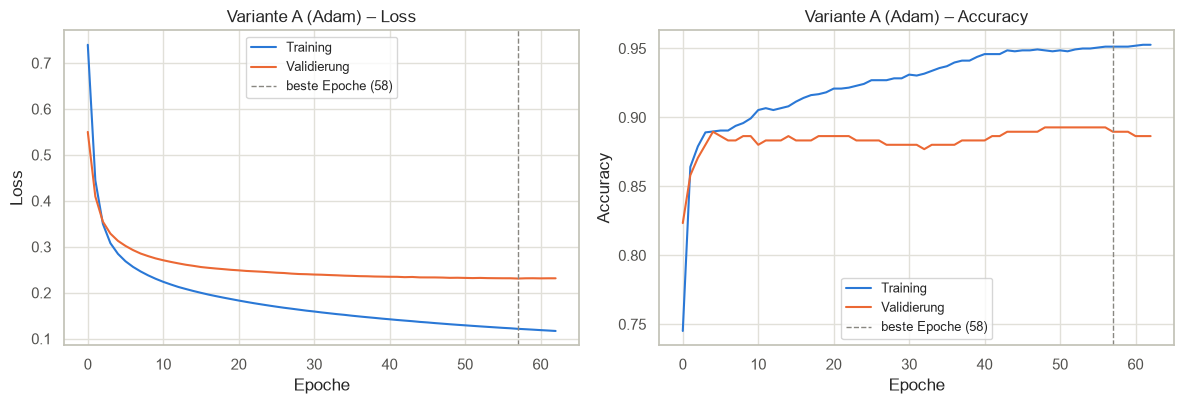

In [23]:
# Quelle: Claude
lernkurven_plot(hist_a, "Variante A (Adam)")

### Kommentar zu den Lernkurven von Variante A

- **Abbruch durch Early Stopping:** Das Training endete nach **63 von 100 Epochen**; die
  beste Epoche (niedrigster `val_loss` = 0,231) war **Epoche 58**. Dank
  `restore_best_weights=True` trägt das Modell wieder die Gewichte dieser Epoche.
- **Verlauf:** Der Validierungs-Loss fällt anfangs steil (0,55 nach Epoche 1 → 0,30 nach
  ca. 6 Epochen) und verbessert sich danach nur noch langsam, bis er ab ca. Epoche 55–60
  in ein Plateau übergeht. Early Stopping wirkt hier als **Plateau-Stopp**, nicht als
  Notbremse gegen ansteigenden `val_loss`.
- **Overfitting?** Mild: Am Ende liegt die Trainings-Accuracy bei ≈ 0,95 gegenüber ≈ 0,89
  auf der Validierung (Trainings-Loss 0,12 vs. Validierungs-Loss 0,23) – die Kurven laufen
  auseinander, aber der `val_loss` **steigt nicht** wieder an. Das Netz merkt sich also
  zunehmend Trainingsdetails, verliert dadurch aber (noch) keine Generalisierung.
- **Underfitting?** Nein – die Validierungs-Accuracy von ≈ 0,89 liegt weit über der naiven
  Baseline von 0,779, und beide Loss-Kurven fallen von Beginn an deutlich.
- **Eignung der Architektur (→ ADR-014):** Die Startkonfiguration ist **geeignet** – kein
  vorzeitiger Abbruch, klarer Lernfortschritt, keine Konvergenz auf Zufallsniveau. Es gibt
  keinen Grund für einen Eingriff; wir behalten Variante A unverändert bei.

In [24]:
# Quelle: Claude
y_pred_a = nn_vorhersage(modell_a, X_val_scaled)

# Gegenprobe: Keras-eigene Evaluation muss dieselbe Accuracy liefern wie sklearn
val_loss_a, val_acc_a = modell_a.evaluate(X_val_scaled, y_val, verbose=0)

# dieselbe evaluiere()-Funktion wie fuer die klassischen Modelle (Schritt 3.3)
vergleichstabelle["MLP Variante A"] = evaluiere(y_val, y_pred_a, "Neural Net")

print("Variante A – Validierungsset:")
print(f"  Keras evaluate():  Loss {val_loss_a:.4f} | Accuracy {val_acc_a:.4f}")
print(f"  sklearn-Metriken:  {vergleichstabelle['MLP Variante A']}")
print(f"  Accuracy identisch: {abs(val_acc_a - vergleichstabelle['MLP Variante A']['Accuracy']) < 1e-3}")
print(f"  Recall je Klasse ({', '.join(TARGET_NAMES)}): "
      f"{recall_score(y_val, y_pred_a, average=None).round(4)}")

Variante A – Validierungsset:
  Keras evaluate():  Loss 0.2309 | Accuracy 0.8896
  sklearn-Metriken:  {'Typ': 'Neural Net', 'Accuracy': 0.8896, 'F1 (weighted)': 0.8864, 'Recall Pathological': 0.6538}
  Accuracy identisch: True
  Recall je Klasse (Normal, Suspect, Pathological): [0.9636 0.6136 0.6538]


### Einordnung Variante A

Mit **Accuracy 0,890 / F1w 0,886** landet Variante A auf dem Niveau der Logistischen
Regression (0,893 / 0,890) und klar hinter dem Random Forest (0,946 / 0,945). Auch das
Fehlerprofil ähnelt der Logistischen Regression: Der Recall der kritischen Klasse
Pathological beträgt nur **0,654** (17 von 26 erkannt), Suspect 0,614. Wenig überraschend –
die Startkonfiguration enthält keinerlei Maßnahme gegen die Klassen-Imbalance
(keine Klassengewichte, → ADR-013), und die Mehrheitsklasse dominiert den Loss.

---
# Schritt 5 – Variante B: Tieferes Netz mit Regularisierung

Vorgaben laut Assignment (**Startkonfiguration**):

- Architektur: `Input → Dense(64, relu) → Dropout(0.3) → Dense(32, relu) → Dense(n_classes, softmax)`
- Optimizer **SGD (statt Adam)** · sonst identisch zu Variante A (Loss, 100 Epochen, `batch_size=32`)
- Early Stopping identisch zu Variante A
- Lernkurven plotten und mit Variante A vergleichen (Wirkung des Dropout? SGD vs. Adam?)
- Zentrale Frage: Warum ist Variante B nicht automatisch besser als Variante A?

## 5.1 Architektur aufbauen und trainieren (Startkonfiguration)

In [25]:
# Quelle: Claude
def baue_variante_b():
    """Architektur der Variante B - wird auch fuer die optimierte Fassung wiederverwendet."""
    return keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(N_CLASSES, activation="softmax"),
    ], name="MLP_Variante_B")


setze_seeds()
modell_b = baue_variante_b()
modell_b.compile(optimizer=keras.optimizers.SGD(),   # Default: lr=0.01, momentum=0.0
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])
modell_b.summary()

Model: "MLP_Variante_B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,587 (14.01 KB)

 Trainable params: 3,587 (14.01 KB)

 Non-trainable params: 0 (0.00 B)

Trainierte Epochen:   52 von max. 100
Beste Epoche:         47 (val_loss = 0.2728)

Variante B (Start) – Validierungsset:
  Accuracy: 0.8864  |  F1 (weighted): 0.8771
  Recall je Klasse (Normal, Suspect, Pathological): [0.9838 0.5    0.6154]


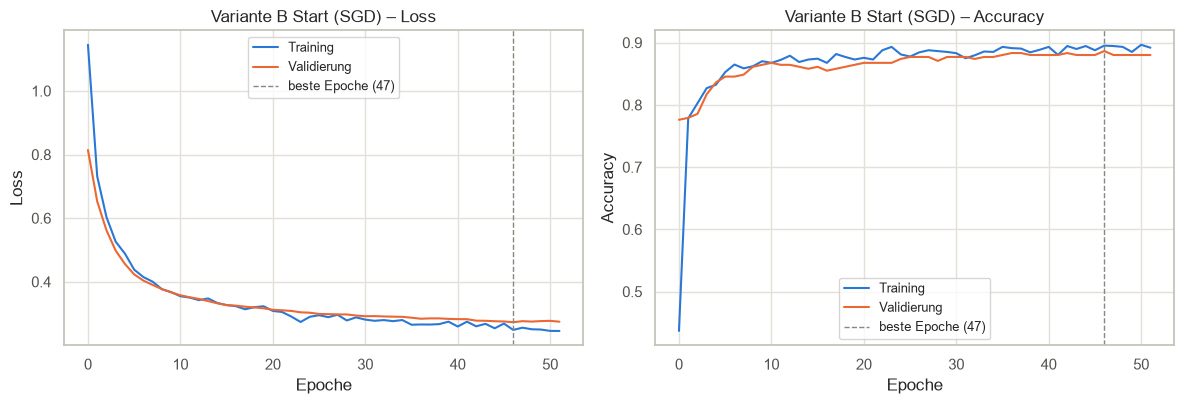

In [26]:
# Quelle: Claude
hist_b = modell_b.fit(X_train_scaled, y_train,
                      validation_data=(X_val_scaled, y_val),
                      epochs=100, batch_size=32,
                      callbacks=[mache_early_stopping(patience=5)], verbose=0)

beste_b = int(np.argmin(hist_b.history["val_loss"])) + 1
print(f"Trainierte Epochen:   {len(hist_b.history['loss'])} von max. 100")
print(f"Beste Epoche:         {beste_b} (val_loss = {min(hist_b.history['val_loss']):.4f})")

res_b_start = evaluiere(y_val, nn_vorhersage(modell_b, X_val_scaled), "Neural Net")
print(f"\nVariante B (Start) – Validierungsset:")
print(f"  Accuracy: {res_b_start['Accuracy']}  |  F1 (weighted): {res_b_start['F1 (weighted)']}")
print(f"  Recall je Klasse ({', '.join(TARGET_NAMES)}): "
      f"{recall_score(y_val, nn_vorhersage(modell_b, X_val_scaled), average=None).round(4)}")

lernkurven_plot(hist_b, "Variante B Start (SGD)")

### Kommentar zu den Lernkurven der Startkonfiguration – Vergleich mit Variante A

- **Abbruch:** Early Stopping beendete das Training nach **52 Epochen** (beste Epoche 47,
  `val_loss` = 0,273). Zum Vergleich: Variante A erreichte `val_loss` 0,231 – Variante B
  bleibt trotz größerer Architektur **schlechter** (Accuracy 0,886 / F1w 0,877; Suspect-Recall
  bricht auf 0,50 ein).
- **Was verändert der Dropout in den Lernkurven?** Der Abstand zwischen Trainings- und
  Validierungskurve verschwindet fast vollständig (Trainings-Accuracy ≈ 0,895 vs.
  Validierungs-Accuracy ≈ 0,886; bei Variante A lagen ≈ 6 Prozentpunkte dazwischen).
  Dropout deaktiviert im Training zufällig 30 % der Neuronen der ersten Schicht – das Netz
  kann sich Trainingsbeispiele nicht „merken“, wodurch die Trainingsmetriken schlechter
  (und leicht verrauscht) ausfallen, während die Validierung – ohne Dropout ausgewertet –
  relativ davon profitiert. Overfitting ist hier also **kein** Problem – aber das war es bei
  Variante A auch kaum.
- **Warum konvergiert SGD anders als Adam?** Adam skaliert die Lernrate **pro Parameter**
  adaptiv anhand der Gradientenhistorie (1. und 2. Moment) und kommt daher mit wenigen
  Epochen weit; SGD nutzt eine **konstante, globale Lernrate** (Default 0,01) ohne
  Momentum. Der Validierungs-Loss fällt entsprechend flacher: nach 5 Epochen steht SGD bei
  ≈ 0,42 (Adam: ≈ 0,30), und selbst nach 52 Epochen ist er mit 0,273 noch weit vom
  Adam-Niveau entfernt. Early Stopping bricht ab, sobald 5 Epochen keine Verbesserung
  bringen – bei einer so flachen, leicht verrauschten Kurve passiert das, **bevor** das
  Netz ausgelernt hat.

## 5.2 Eingriff in die Startkonfiguration (→ ADR-014)

Die Lernkurven zeigen: Die Architektur ist nicht das Problem – die **Optimierung** ist es.
Gemäß den Freiheitsgraden des Assignments greifen wir dokumentiert ein:

1. **SGD mit Momentum 0,9** (weiterhin SGD, wie vom Assignment vorgegeben – kein Wechsel
   zu Adam): Momentum akkumuliert die Gradientenrichtung über die Schritte und beschleunigt
   die Konvergenz in flachen Tälern erheblich – der Standard-Zusatz für SGD aus dem Kurs.
2. **`patience` 5 → 10**: Die SGD-Kurve fällt langsam und leicht verrauscht; eine höhere
   Patience verhindert, dass ein zufälliges 5-Epochen-Plateau das Training vorzeitig beendet.

Architektur, Loss, Epochenbudget und Batch-Größe bleiben unverändert. Ob wirklich der
Optimierer der Engpass ist – und nicht bloß das Abbruchkriterium – prüfen wir anschließend
mit einer **Gegenprobe** (Abschnitt 5.3).

Trainierte Epochen:   55 von max. 100
Beste Epoche:         45 (val_loss = 0.2040)


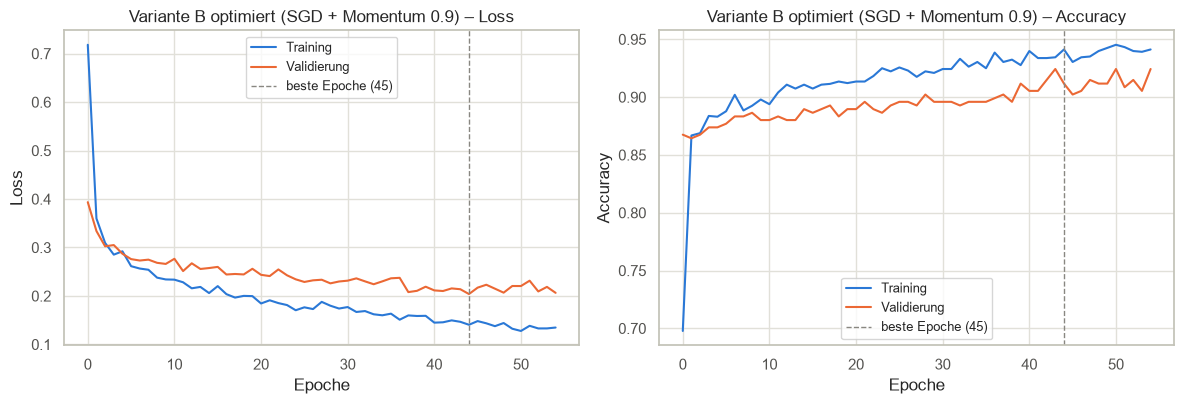

In [27]:
# Quelle: Claude
setze_seeds()
modell_b_opt = baue_variante_b()
modell_b_opt.compile(optimizer=keras.optimizers.SGD(momentum=0.9),
                     loss="sparse_categorical_crossentropy",
                     metrics=["accuracy"])

hist_b_opt = modell_b_opt.fit(X_train_scaled, y_train,
                              validation_data=(X_val_scaled, y_val),
                              epochs=100, batch_size=32,
                              callbacks=[mache_early_stopping(patience=10)], verbose=0)

beste_b_opt = int(np.argmin(hist_b_opt.history["val_loss"])) + 1
print(f"Trainierte Epochen:   {len(hist_b_opt.history['loss'])} von max. 100")
print(f"Beste Epoche:         {beste_b_opt} (val_loss = {min(hist_b_opt.history['val_loss']):.4f})")

lernkurven_plot(hist_b_opt, "Variante B optimiert (SGD + Momentum 0.9)")

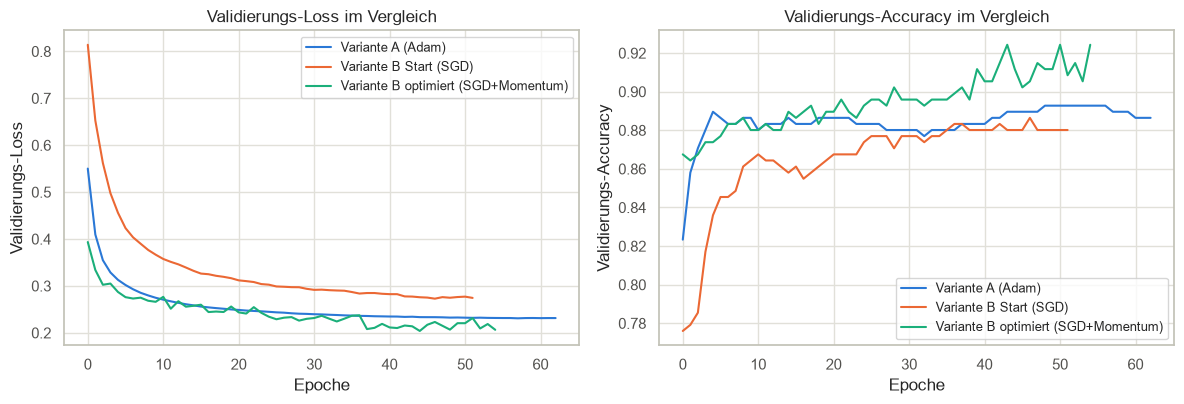

In [28]:
# Quelle: Claude
# Direkter Vergleich der Validierungskurven aller drei Trainingslaeufe
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
kurven = [("Variante A (Adam)", hist_a, "#2a78d6"),
          ("Variante B Start (SGD)", hist_b, "#eb6834"),
          ("Variante B optimiert (SGD+Momentum)", hist_b_opt, "#1baf7a")]
for ax, metrik, label in [(axes[0], "val_loss", "Validierungs-Loss"),
                          (axes[1], "val_accuracy", "Validierungs-Accuracy")]:
    for name, hist, farbe in kurven:
        ax.plot(hist.history[metrik], color=farbe, label=name)
    ax.set_xlabel("Epoche")
    ax.set_ylabel(label)
    ax.set_title(label + " im Vergleich")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [29]:
# Quelle: Claude
y_pred_b_opt = nn_vorhersage(modell_b_opt, X_val_scaled)
vergleichstabelle["MLP Variante B (optimiert)"] = evaluiere(y_val, y_pred_b_opt, "Neural Net")

print("Variante B (optimiert) – Validierungsset:")
print(f"  {vergleichstabelle['MLP Variante B (optimiert)']}")
print(f"  Recall je Klasse ({', '.join(TARGET_NAMES)}): "
      f"{recall_score(y_val, y_pred_b_opt, average=None).round(4)}")

print("\nZwischenstand der Vergleichstabelle (Validierungsset):")
display(pd.DataFrame(vergleichstabelle).T)

Variante B (optimiert) – Validierungsset:
  {'Typ': 'Neural Net', 'Accuracy': 0.9117, 'F1 (weighted)': 0.9085, 'Recall Pathological': 0.6538}
  Recall je Klasse (Normal, Suspect, Pathological): [0.9798 0.6818 0.6538]

Zwischenstand der Vergleichstabelle (Validierungsset):


,Typ,Accuracy,F1 (weighted),Recall Pathological
Logistic Regression,Klassisch,0.8927,0.8895,0.6538
Random Forest,Klassisch,0.9464,0.9451,0.8846
SVM (RBF),Klassisch,0.9022,0.8963,0.6923
MLP Variante A,Neural Net,0.8896,0.8864,0.6538
MLP Variante B (optimiert),Neural Net,0.9117,0.9085,0.6538


## 5.3 Gegenprobe: War es wirklich der Optimierer?

Wir haben zwei Dinge gleichzeitig verändert (Momentum **und** Patience). Um sauber zu trennen,
welcher der beiden Eingriffe wirkt, trainieren wir dieselbe Architektur ein drittes Mal –
mit **erhöhter Patience, aber ohne Momentum**. Verbessert sich das Ergebnis dadurch kaum, ist
der Optimierer die Ursache und nicht das Abbruchkriterium.

In [30]:
# Quelle: Claude
setze_seeds()
modell_b_probe = baue_variante_b()
modell_b_probe.compile(optimizer=keras.optimizers.SGD(),   # bewusst OHNE Momentum
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"])
hist_b_probe = modell_b_probe.fit(X_train_scaled, y_train,
                                  validation_data=(X_val_scaled, y_val),
                                  epochs=100, batch_size=32,
                                  callbacks=[mache_early_stopping(patience=10)], verbose=0)

probe = evaluiere(y_val, nn_vorhersage(modell_b_probe, X_val_scaled), "Neural Net")

vergleich_b = pd.DataFrame({
    "B Start (SGD, patience=5)": {
        "Epochen": len(hist_b.history["loss"]),
        "bester val_loss": round(min(hist_b.history["val_loss"]), 4),
        "F1 (weighted)": res_b_start["F1 (weighted)"]},
    "B Gegenprobe (SGD, patience=10)": {
        "Epochen": len(hist_b_probe.history["loss"]),
        "bester val_loss": round(min(hist_b_probe.history["val_loss"]), 4),
        "F1 (weighted)": probe["F1 (weighted)"]},
    "B optimiert (SGD+Momentum, patience=10)": {
        "Epochen": len(hist_b_opt.history["loss"]),
        "bester val_loss": round(min(hist_b_opt.history["val_loss"]), 4),
        "F1 (weighted)": vergleichstabelle["MLP Variante B (optimiert)"]["F1 (weighted)"]},
}).T
display(vergleich_b)

,Epochen,bester val_loss,F1 (weighted)
"B Start (SGD, patience=5)",52.0,0.2728,0.8771
"B Gegenprobe (SGD, patience=10)",76.0,0.2643,0.8818
"B optimiert (SGD+Momentum, patience=10)",55.0,0.2040,0.9085


### Ergebnis der Gegenprobe und Wirkung des Eingriffs

Die Gegenprobe ist eindeutig: **Die höhere Patience allein bringt fast nichts.** Ohne Momentum
läuft das Training zwar 76 statt 52 Epochen, der beste `val_loss` verbessert sich aber nur von
0,273 auf 0,264 und der F1w von 0,877 auf 0,882 – beide bleiben unter Variante A (0,886). Erst
mit Momentum fällt der `val_loss` auf **0,204**. Der Engpass war also tatsächlich das
**Optimierungsverfahren**, nicht das Abbruchkriterium; die längere Patience ist nur eine
sinnvolle Absicherung gegen verfrühten Abbruch, nicht die eigentliche Verbesserung.

Mit Momentum konvergiert dieselbe Architektur **schneller und tiefer**: bester `val_loss`
0,204 in Epoche 45 (Start-Variante: 0,273 in Epoche 47) – sogar besser als Variante A
(0,231). Auf dem Validierungsset erreicht die optimierte Variante B **Accuracy 0,912 /
F1w 0,909** und übertrifft damit Variante A (0,890 / 0,886) und alle Nicht-Baum-Modelle;
der Suspect-Recall steigt von 0,50 auf 0,68. In die Vergleichstabelle geht die
**optimierte** Variante B ein; Startkonfiguration und Gegenprobe bleiben dokumentiert.

### Zentrale Frage: Warum ist Variante B nicht automatisch besser als Variante A?

Die Startkonfiguration von B war trotz größerer Architektur und Regularisierung
**schlechter** als A (F1w 0,877 vs. 0,886) – aus vier Gründen:

1. **Kapazität nützt nur, wenn die Optimierung sie erschließt.** Mehr Schichten machen die
   Loss-Landschaft komplexer; mit reinem SGD (konstante Lernrate, kein Momentum) blieb das
   Training in einem flachen Bereich stecken, den Early Stopping dann als Konvergenz
   fehlinterpretierte. Erst SGD + Momentum holt das Potenzial der Architektur heraus.
2. **Regularisierung hilft nur gegen ein Problem, das man hat.** Dropout bekämpft
   Overfitting – Variante A hat aber nur mildes Overfitting gezeigt. Der Preis (langsameres,
   verrauschteres Training, weniger effektive Kapazität pro Update) fällt trotzdem an.
3. **Kleine Datenbasis:** Mit 1.479 Trainingsbeispielen und 21 Features ist die Aufgabe zu
   klein, als dass Tiefe per se einen Vorteil brächte – das Verhältnis von Parametern
   (B: 3.587 vs. A: 1.603) zu Datenmenge verschiebt sich eher ungünstig.
4. **Der Optimizer ist Teil des Modells.** A und B unterscheiden sich nicht nur in der
   Architektur, sondern auch im Optimierer (Adam vs. SGD) – der Vergleich „tiefer +
   Regularisierung vs. flach“ ist dadurch konfundiert. Unsere Gegenproben zeigen: Der
   Optimierer-Effekt dominiert hier den Architektur-Effekt.

**Einordnung:** Auch die optimierte Variante B (F1w 0,909) bleibt hinter dem Random Forest
(F1w 0,945) – insbesondere beim Recall der kritischen Klasse Pathological (0,654 vs. 0,885).

---
# Schritt 6 – Modellvergleich, Optimierung und finale Evaluation

Laut Assignment umfasst Schritt 6:

1. Vergleichstabelle aller fünf Modelle auf dem Validierungsset
2. Hyperparameter-Optimierung für das **beste** Modell
   (klassische Modelle: `GridSearchCV` mit mind. 2 Parametern · neuronale Netze: KerasTuner)
3. Finale Evaluation des optimierten Modells **exklusiv auf dem Testset – nur einmal!**
4. Konfusionsmatrix (n×n) ausgeben und interpretieren
5. Ergänzend den `classification_report` (Precision, Recall, F1 je Klasse)

## 6.1 Vergleichstabelle aller Modelle (Validierungsset)

Die Tabelle fasst die in Schritt 3–5 gesammelten Ergebnisse zusammen. Alle Zahlen stammen vom
**Validierungsset** (317 Samples) – das Testset ist bis Abschnitt 6.4 unberührt.

In [31]:
# Quelle: Claude
notizen = {
    "Logistic Regression": "linear; übersieht 9 von 26 Pathological",
    "Random Forest": "bestes Modell in allen Metriken; Defaults",
    "SVM (RBF)": "gute Accuracy, schwächster Suspect-Recall (0,57)",
    "MLP Variante A": "Startkonfig. geeignet; Niveau der LogReg",
    "MLP Variante B (optimiert)": "SGD+Momentum, patience=10 (→ ADR-014)",
}

tabelle = pd.DataFrame(vergleichstabelle).T
tabelle["Notizen"] = pd.Series(notizen)
tabelle = tabelle[["Typ", "Accuracy", "F1 (weighted)", "Recall Pathological", "Notizen"]]
display(tabelle)

# Referenzpunkt aus Schritt 3.3 (DummyClassifier) zum Einordnen
print(f"Naive Baseline (DummyClassifier): Accuracy = {baseline['Accuracy']} | "
      f"Recall Pathological = {baseline['Recall Pathological']}")

,Typ,Accuracy,F1 (weighted),Recall Pathological,Notizen
Logistic Regression,Klassisch,0.8927,0.8895,0.6538,linear; übersieht 9 von 26 Pathological
Random Forest,Klassisch,0.9464,0.9451,0.8846,bestes Modell in allen Metriken; Defaults
SVM (RBF),Klassisch,0.9022,0.8963,0.6923,"gute Accuracy, schwächster Suspect-Recall (0,57)"
MLP Variante A,Neural Net,0.8896,0.8864,0.6538,Startkonfig. geeignet; Niveau der LogReg
MLP Variante B (optimiert),Neural Net,0.9117,0.9085,0.6538,"SGD+Momentum, patience=10 (→ ADR-014)"


Naive Baseline (DummyClassifier): Accuracy = 0.7792 | Recall Pathological = 0.0


### Auswahl des besten Modells (→ ADR-015)

| Modell | Typ | Accuracy | F1 (weighted) | Recall Pathological |
|---|---|---|---|---|
| Logistic Regression | Klassisch | 0,8927 | 0,8895 | 0,6538 |
| **Random Forest** | **Klassisch** | **0,9464** | **0,9451** | **0,8846** |
| k-NN / **SVM (RBF)** | Klassisch | 0,9022 | 0,8963 | 0,6923 |
| MLP Variante A | Neural Net | 0,8896 | 0,8864 | 0,6538 |
| MLP Variante B (optimiert) | Neural Net | 0,9117 | 0,9085 | 0,6538 |

**Der Random Forest ist das beste Modell** – und zwar eindeutig: Er führt in *allen drei*
Metriken gleichzeitig. Besonders deutlich ist der Vorsprung beim fachlich entscheidenden
**Recall der Klasse Pathological** (0,885 vs. 0,654–0,692 bei allen anderen): Er erkennt
23 von 26 pathologischen Fällen, die übrigen Modelle nur 17–18.

Bemerkenswert: Die beiden neuronalen Netze schlagen den Random Forest **nicht**. Bei
1.479 Trainingsbeispielen und 21 tabellarischen Features spielt ein MLP seine Stärken
(Repräsentationslernen aus großen, unstrukturierten Datenmengen) nicht aus, während
Baumensembles auf genau dieser Datenform besonders stark sind.

Zur Einordnung liefert der `DummyClassifier` aus Schritt 3.3 den Referenzpunkt: 77,9 %
Accuracy bei einem Recall von **0,0** auf Pathological – er erreicht also fast die Accuracy
der Logistischen Regression, ohne einen einzigen kritischen Fall zu erkennen. Genau deshalb
ist Accuracy hier als alleiniges Erfolgsmaß untauglich (→ ADR-002).

**Konsequenz für die Optimierung:** Da das beste Modell ein klassisches Modell ist, verwenden
wir laut Assignment **`GridSearchCV`**. KerasTuner käme zum Einsatz, wenn ein neuronales Netz
gewonnen hätte – das ist hier nicht der Fall.

## 6.2 Hyperparameter-Optimierung des Random Forest mit GridSearchCV

Wir optimieren **vier** Parameter (gefordert: mindestens 2):

| Parameter | Werte | Warum dieser Parameter? |
|---|---|---|
| `n_estimators` | 100, 300 | Anzahl Bäume – mehr Bäume stabilisieren die Mittelung |
| `max_depth` | None, 10, 20 | Tiefenbegrenzung als **Regularisierung** gegen Overfitting |
| `min_samples_leaf` | 1, 2, 4 | Mindestgröße der Blätter – glättet die Entscheidungsgrenzen |
| `class_weight` | None, balanced, balanced_subsample | **Umgang mit der Klassen-Imbalance** (→ ADR-013) |

Damit werden 2 × 3 × 3 × 3 = **54 Kombinationen** × 5 Folds = 270 Modelle trainiert.

Mit `class_weight` beantworten wir zugleich die in Schritt 1 offengelassene Frage, wie wir mit
der Imbalance umgehen (→ ADR-013): Statt sie vorab zu setzen, lassen wir die Kreuzvalidierung
**datengetrieben** entscheiden. `balanced` gewichtet die Klassen im Loss umgekehrt
proportional zu ihrer Häufigkeit – ein pathologischer Fall zählt damit ca. 9-mal so viel wie
ein normaler.

Die Suche läuft mit `StratifiedKFold(5)` **nur auf den Trainingsdaten**. Wir lassen zu jeder
Kombination alle drei Metriken berechnen (`scoring` als Dictionary) und `refit` auf
`f1_weighted` – die im Assignment geforderte Hauptmetrik.

In [32]:
# Quelle: Claude
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced", "balanced_subsample"],
}

n_kombinationen = int(np.prod([len(v) for v in param_grid.values()]))
print(f"Parameterkombinationen: {n_kombinationen}")
print(f"Trainingslaeufe gesamt: {n_kombinationen * cv.get_n_splits()}\n")

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring=scoring,        # dasselbe Dictionary wie in Schritt 3.2
    refit="f1_weighted",    # nach dieser Metrik wird das beste Modell gewaehlt
    cv=cv,                  # StratifiedKFold(5, shuffle=True, random_state=42)
    n_jobs=-1,              # alle CPU-Kerne nutzen
    return_train_score=True,  # Trainingsscore zum Vergleich (Overfitting-Check)
)

start = time.perf_counter()
grid.fit(X_train, y_train)
print(f"Laufzeit: {time.perf_counter() - start:.1f} s\n")

print("Beste Parameter (refit auf F1 weighted):")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBester CV-F1w: {grid.best_score_:.4f}  (Default-RF in Schritt 3.2: 0.9339)")
print("\nHinweis: Dieser CV-Score ist leicht optimistisch – er wurde genutzt,")
print("um die Parameter auszuwaehlen (Selection Bias). Der ehrliche Wert")
print("folgt in Abschnitt 6.5 auf den Testdaten.")

Parameterkombinationen: 54
Trainingslaeufe gesamt: 270



Laufzeit: 8.2 s

Beste Parameter (refit auf F1 weighted):
  class_weight: balanced_subsample
  max_depth: 20
  min_samples_leaf: 1
  n_estimators: 100

Bester CV-F1w: 0.9356  (Default-RF in Schritt 3.2: 0.9339)

Hinweis: Dieser CV-Score ist leicht optimistisch – er wurde genutzt,
um die Parameter auszuwaehlen (Selection Bias). Der ehrliche Wert
folgt in Abschnitt 6.5 auf den Testdaten.


In [33]:
# Quelle: Claude
# Top-5-Konfigurationen: F1w liegt extrem eng zusammen, der Pathological-Recall nicht
res = pd.DataFrame(grid.cv_results_)
spalten = ["rank_test_f1_weighted",
           "param_n_estimators", "param_max_depth", "param_min_samples_leaf",
           "param_class_weight",
           "mean_test_f1_weighted", "mean_train_f1_weighted",
           "mean_test_recall_pathological", "mean_test_accuracy"]
top5 = res.sort_values("rank_test_f1_weighted")[spalten].head(5)
top5.columns = ["Rang", "n_estimators", "max_depth", "min_samples_leaf", "class_weight",
                "CV F1w", "Train F1w", "CV Recall Patho", "CV Accuracy"]
display(top5.round(4).reset_index(drop=True))

,Rang,n_estimators,max_depth,min_samples_leaf,class_weight,CV F1w,Train F1w,CV Recall Patho,CV Accuracy
0,1,100,20,1,balanced_subsample,0.9356,0.9995,0.8380,0.9378
1,2,100,None,2,balanced_subsample,0.9349,0.9906,0.8700,0.9358
2,2,100,20,2,balanced_subsample,0.9349,0.9906,0.8700,0.9358
3,4,100,None,1,balanced_subsample,0.9348,0.9995,0.8380,0.9371
4,5,100,20,1,balanced,0.9346,0.9913,0.9187,0.9337


### Interpretation der Suchergebnisse – und eine bewusste Abweichung vom Grid-Sieger

Die Top-5-Konfigurationen liegen im **F1 (weighted) praktisch gleichauf**: 0,9346 bis 0,9356 –
eine Spanne von 0,001, die weit **innerhalb** der CV-Streuung liegt (in Schritt 3.2 lag die
Standardabweichung des F1w bei ± 0,016). Nach dieser Metrik sind die fünf Modelle statistisch
nicht unterscheidbar.

Beim **Recall der Klasse Pathological** unterscheiden sie sich dagegen erheblich:
**0,838 bis 0,919**. Und genau hier greift unsere in Schritt 1 festgelegte Metrikstrategie
(→ ADR-002): Wenn F1 (weighted) nicht trennscharf ist, entscheidet als zweites Kriterium der
Recall der kritischen Klasse.

Die Spalte **Train F1w** (durch `return_train_score=True` mitberechnet) zeigt nebenbei, wie
stark alle Kandidaten die Trainingsdaten auswendig lernen: 0,99 bis 1,00 gegenüber 0,93 auf
den Validierungs-Folds. Das ist für unbeschränkte Random Forests normal – jeder Baum wächst
bis zur perfekten Trennung – und kein Alarmzeichen, solange die CV-Werte stabil bleiben. Es
erklärt aber, warum die Tiefenbegrenzung (`max_depth`) hier kaum etwas verbessert: Die
Ensemble-Mittelung übernimmt die Regularisierung bereits.

**Gewählte Konfiguration (→ ADR-015):**
`class_weight="balanced"`, `max_depth=None`, `min_samples_leaf=1`, `n_estimators=100` –
CV-F1w 0,9346 (0,001 unter dem Grid-Sieger) bei **CV-Recall Pathological 0,919** statt 0,838.
Wir tauschen also einen methodisch bedeutungslosen F1w-Unterschied gegen 8 Prozentpunkte
Recall auf der Klasse, deren Übersehen im Praxiskontext den größten Schaden verursacht.

Diese Regel schreiben wir **als Code** und nicht als fest eingetragene Parameterliste:
„Nimm alle Konfigurationen, deren F1w höchstens um `TOLERANZ` unter dem Bestwert liegt, und
wähle daraus die mit dem höchsten Recall auf Pathological." So kann die dokumentierte
Begründung nicht mehr von der tatsächlich verwendeten Konfiguration abweichen – ändert
jemand später das Parametergitter, leitet sich die Wahl automatisch neu ab. Die Toleranz von
0,002 entspricht etwa einem Fünftel der CV-Streuung; eine Kontrollrechnung zeigt, dass auch
0,005 dieselbe Konfiguration liefert. (Deutlich weitere Bänder – etwa eine volle
Standardabweichung – würden Konfigurationen mit spürbar schlechterem F1w zulassen; deshalb
grenzen wir eng ein.)

Damit ist auch **ADR-013 entschieden:** Der Klassen-Imbalance begegnen wir über
`class_weight="balanced"` – die Kreuzvalidierung bestätigt, dass die Gewichtung den Recall der
kleinen Klassen hebt, ohne die Gesamtgüte zu beschädigen.

Wichtig: Diese Auswahl beruht **ausschließlich auf Kreuzvalidierungs-Ergebnissen der
Trainingsdaten** – weder das Validierungs- noch das Testset waren daran beteiligt.

In [34]:
# Quelle: Claude
# Die Auswahlregel aus ADR-015 als ausfuehrbarer Code statt als handgeschriebenes Dict.
# Vorteil: Die gewaehlte Konfiguration kann nicht mehr von den Suchergebnissen abweichen -
# aendert sich das Parametergitter, leitet die Regel die Wahl automatisch neu ab.
TOLERANZ = 0.002   # ca. ein Fuenftel der CV-Streuung -> klar innerhalb des Rauschens

bester_f1w = res["mean_test_f1_weighted"].max()
gleichwertig = res[res["mean_test_f1_weighted"] >= bester_f1w - TOLERANZ]
gewaehlt = gleichwertig.loc[gleichwertig["mean_test_recall_pathological"].idxmax()]
finale_parameter = gewaehlt["params"]

sieger = res.loc[res["mean_test_f1_weighted"].idxmax()]
print(f"Statistisch gleichwertig zum Bestwert {bester_f1w:.4f} (Toleranz {TOLERANZ}): "
      f"{len(gleichwertig)} von {len(res)} Konfigurationen")
print("\nDavon die mit dem hoechsten Recall Pathological:")
for k, v in finale_parameter.items():
    print(f"  {k}: {v}")
print(f"\n  CV F1w                 {gewaehlt['mean_test_f1_weighted']:.4f}"
      f"   (Grid-Sieger: {sieger['mean_test_f1_weighted']:.4f})")
print(f"  CV Recall Pathological {gewaehlt['mean_test_recall_pathological']:.4f}"
      f"   (Grid-Sieger: {sieger['mean_test_recall_pathological']:.4f})")

# Robustheitspruefung: haengt die Wahl an der genauen Toleranz?
kontrolle = res[res["mean_test_f1_weighted"] >= bester_f1w - 0.005]
gleich = kontrolle.loc[kontrolle["mean_test_recall_pathological"].idxmax()]["params"] == finale_parameter
print(f"\n  Kontrolle mit Toleranz 0.005: {'dieselbe Wahl' if gleich else 'andere Wahl!'}")

Statistisch gleichwertig zum Bestwert 0.9356 (Toleranz 0.002): 10 von 54 Konfigurationen

Davon die mit dem hoechsten Recall Pathological:
  class_weight: balanced
  max_depth: None
  min_samples_leaf: 1
  n_estimators: 100

  CV F1w                 0.9346   (Grid-Sieger: 0.9356)
  CV Recall Pathological 0.9187   (Grid-Sieger: 0.8380)

  Kontrolle mit Toleranz 0.005: dieselbe Wahl


In [35]:
# Quelle: Claude
# Kontrollblick auf dem Validierungsset (NICHT Teil der Auswahlentscheidung).
# grid.best_estimator_ ist der Grid-Sieger - GridSearchCV hat ihn bereits
# automatisch auf allen Trainingsdaten neu trainiert.
kandidaten = {
    "RF Default (Schritt 3)":
        RandomForestClassifier(random_state=RANDOM_STATE).fit(X_train, y_train),
    "Grid-Sieger (best_estimator_)":
        grid.best_estimator_,
    "unsere Wahl (→ ADR-015)":
        RandomForestClassifier(random_state=RANDOM_STATE, **finale_parameter).fit(X_train, y_train),
}

for tag, modell in kandidaten.items():
    p = modell.predict(X_val)
    r = recall_score(y_val, p, average=None).round(4)
    print(f"{tag:30s} F1w {f1_score(y_val, p, average='weighted'):.4f}"
          f" | Recall {dict(zip(TARGET_NAMES, r))}")

RF Default (Schritt 3)         F1w 0.9451 | Recall {'Normal': np.float64(0.9838), 'Suspect': np.float64(0.7727), 'Pathological': np.float64(0.8846)}
Grid-Sieger (best_estimator_)  F1w 0.9413 | Recall {'Normal': np.float64(0.9838), 'Suspect': np.float64(0.7273), 'Pathological': np.float64(0.9231)}
unsere Wahl (→ ADR-015)        F1w 0.9384 | Recall {'Normal': np.float64(0.9514), 'Suspect': np.float64(0.8636), 'Pathological': np.float64(0.9231)}


Der Kontrollblick bestätigt das erwartete Muster: Die Klassengewichtung verschiebt Leistung
von der großen zur kleinen Klasse – der Recall für Suspect steigt von 0,773 auf 0,864, für
Pathological von 0,885 auf 0,923, während Normal leicht von 0,984 auf 0,951 nachgibt. Genau
dieser Kompromiss ist im medizinischen Screening gewollt (→ ADR-002).

Aufschlussreich ist der **Grid-Sieger** in der mittleren Zeile: Er erreicht bei Pathological
denselben Recall wie unsere Wahl (0,923), fällt bei **Suspect** aber auf 0,727 – und liegt
damit sogar unter den Defaults (0,773). Sein leicht höherer F1w (0,941 vs. 0,938) entsteht
also dadurch, dass er die große Klasse Normal besser bedient und die mittlere Klasse
vernachlässigt. Das bestätigt im Nachhinein, warum wir uns nicht allein auf den F1w verlassen
haben (→ ADR-002).

## 6.3 Wahrscheinlichkeiten, ROC-AUC und Schwellwert-Analyse

Bisher haben wir nur **harte Klassenzuweisungen** bewertet. Ein Random Forest liefert über
`predict_proba()` aber Wahrscheinlichkeiten für alle drei Klassen; die Zuordnung entsteht erst
daraus durch `argmax` (die Klasse mit der höchsten Wahrscheinlichkeit gewinnt).

Das eröffnet zwei zusätzliche Auswertungen, die im Kurs bei imbalancierten Daten eingeführt
wurden:

1. **ROC-AUC** – misst die Trennfähigkeit **unabhängig von der Entscheidungsschwelle**.
   Alle bisherigen Metriken (F1, Recall) hängen von der `argmax`-Regel ab; die AUC bewertet
   das Modell selbst.
2. **Schwellwert-Anpassung** – für ein Screening-System ist `argmax` nicht zwingend die
   richtige Regel. Wir können bewusst sagen: *„Sobald die Wahrscheinlichkeit für
   Pathological einen Schwellwert t überschreitet, alarmiere – auch wenn eine andere Klasse
   rechnerisch wahrscheinlicher ist."* Das erkauft Recall gegen Präzision.

**Wichtig:** Diese Analyse läuft ausschließlich auf den **Validierungsdaten**. Das Testset
bleibt bis Abschnitt 6.5 unberührt.

In [36]:
# Quelle: Claude
from sklearn.metrics import PrecisionRecallDisplay, precision_score, roc_auc_score

# Modell mit der in 6.2 gewaehlten Konfiguration, trainiert auf den Trainingsdaten
rf_gewaehlt = RandomForestClassifier(random_state=RANDOM_STATE, **finale_parameter)
rf_gewaehlt.fit(X_train, y_train)

# Wahrscheinlichkeiten statt harter Labels: eine Spalte je Klasse, Zeilensumme 1
proba_val = rf_gewaehlt.predict_proba(X_val)
print("Form der Wahrscheinlichkeitsmatrix:", proba_val.shape,
      "| Zeilensumme:", proba_val.sum(axis=1)[:3].round(4))

# ROC-AUC one-vs-rest: je Klasse "diese Klasse vs. alle anderen", dann gemittelt
print(f"\nROC-AUC (ovr, macro):    {roc_auc_score(y_val, proba_val, multi_class='ovr', average='macro'):.4f}")
print(f"ROC-AUC (ovr, weighted): {roc_auc_score(y_val, proba_val, multi_class='ovr', average='weighted'):.4f}")
print("\nHinweis: Fuer die SVM waere dafuer SVC(probability=True) noetig - das trainiert")
print("intern zusaetzliche Modelle und ist in neueren sklearn-Versionen abgekuendigt.")
print("Wir werten die AUC daher nur fuer das gewaehlte Modell aus.")

Form der Wahrscheinlichkeitsmatrix: (317, 3) | Zeilensumme: [1. 1. 1.]

ROC-AUC (ovr, macro):    0.9844
ROC-AUC (ovr, weighted): 0.9881

Hinweis: Fuer die SVM waere dafuer SVC(probability=True) noetig - das trainiert
intern zusaetzliche Modelle und ist in neueren sklearn-Versionen abgekuendigt.
Wir werten die AUC daher nur fuer das gewaehlte Modell aus.


C:\Users\maksb\AppData\Local\Temp\claude\c--Users-maksb-OneDrive-Desktop-ML-Projekt\faa8d84d-dd34-4c30-b197-2e352d9b6a5e\scratchpad\venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


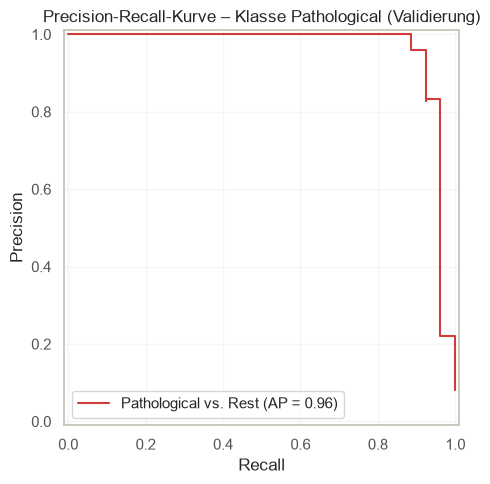

In [37]:
# Quelle: Claude
# Precision-Recall-Kurve fuer die kritische Klasse (Pathological vs. Rest).
# Bei starker Imbalance aussagekraeftiger als die ROC-Kurve, weil sie die
# grosse Klasse Normal nicht in den True Negatives "verstecken" kann.
fig, ax = plt.subplots(figsize=(6.5, 5))
PrecisionRecallDisplay.from_predictions(
    (y_val == 2).astype(int), proba_val[:, 2],
    name="Pathological vs. Rest", ax=ax, color="#d03b3b")
ax.set_title("Precision-Recall-Kurve – Klasse Pathological (Validierung)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# Quelle: Claude
# Entscheidungsregel: P(Pathological) >= t  ->  Pathological,
# sonst argmax der beiden uebrigen Klassen.
zeilen = []
for t in [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10]:
    pred_t = np.where(proba_val[:, 2] >= t, 2, proba_val[:, :2].argmax(axis=1))
    zeilen.append({
        "Schwelle t": t,
        "Recall Patho": round(recall_score(y_val, pred_t, labels=[2], average="macro"), 3),
        "Precision Patho": round(precision_score(y_val, pred_t, labels=[2],
                                                 average="macro", zero_division=0), 3),
        "Recall Suspect": round(recall_score(y_val, pred_t, labels=[1], average="macro"), 3),
        "Accuracy": round(accuracy_score(y_val, pred_t), 3),
        "F1 (weighted)": round(f1_score(y_val, pred_t, average="weighted"), 4),
    })
schwellen = pd.DataFrame(zeilen).set_index("Schwelle t")

# Referenz: die normale argmax-Regel
pred_argmax = proba_val.argmax(axis=1)
print(f"argmax-Standardregel: Recall Patho "
      f"{recall_score(y_val, pred_argmax, labels=[2], average='macro'):.3f} | "
      f"Accuracy {accuracy_score(y_val, pred_argmax):.3f} | "
      f"F1w {f1_score(y_val, pred_argmax, average='weighted'):.4f}")
print(f"Pathological-Faelle im Validierungsset: {(y_val == 2).sum()}\n")
display(schwellen)

argmax-Standardregel: Recall Patho 0.923 | Accuracy 0.937 | F1w 0.9384
Pathological-Faelle im Validierungsset: 26



,Recall Patho,Precision Patho,Recall Suspect,Accuracy,F1 (weighted)
Schwelle t,,,,,
0.50,0.885,0.958,0.864,0.934,0.9358
0.40,0.923,0.857,0.864,0.934,0.9354
0.30,0.923,0.857,0.864,0.934,0.9354
0.25,0.962,0.833,0.864,0.934,0.9357
0.20,0.962,0.758,0.841,0.924,0.9268
0.15,0.962,0.694,0.818,0.915,0.9182
0.10,0.962,0.581,0.795,0.893,0.8994


### Interpretation – und warum wir die Schwelle **nicht** verschieben

Die ROC-AUC von **0,98** (ovr, weighted) bestätigt unabhängig von jeder Schwellenwahl, dass
das Modell die Klassen sehr gut trennt. Die Rangfolge aus der Vergleichstabelle steht damit
auf einem zweiten, methodisch andersartigen Bein.

Die Schwellwert-Tabelle zeigt das erwartete Bild: Senkt man t von 0,50 auf 0,25, steigt der
Recall für Pathological von 0,885 auf **0,962** – und die Precision fällt von 0,958 auf 0,833.
Unterhalb von 0,20 bricht die Precision deutlich ein (0,758 → 0,581), ohne dass der Recall
noch weiter steigt.

**Unsere Entscheidung: Wir bleiben bei der `argmax`-Standardregel.** Begründung:

- Der scheinbare Gewinn zwischen t = 0,50 und t = 0,25 beträgt **exakt zwei Fälle** (von
  23 auf 25 der 26 pathologischen Validierungsfälle). Bei dieser Stichprobengröße ist das
  keine belastbare Verbesserung, sondern liegt im Rauschen – dieselbe Vorsicht, die wir in
  Abschnitt 7.1 auf die Testergebnisse anwenden.
- Eine auf 26 Fällen kalibrierte Schwelle würde mit hoher Wahrscheinlichkeit **auf das
  Validierungsset überangepasst** sein und auf neuen Daten nicht halten.
- Die Klassengewichtung (`class_weight="balanced"`, → ADR-013) verschiebt die
  Wahrscheinlichkeiten bereits zugunsten der kleinen Klassen. Eine zusätzliche
  Schwellenverschiebung würde denselben Effekt ein zweites Mal anwenden.

**Was wir stattdessen festhalten:** Die Schwelle ist der richtige Stellhebel, sobald
*fachlich begründete Fehlerkosten* vorliegen (z. B. „ein übersehener Fall kostet so viel wie
X Fehlalarme") und genügend Daten für eine stabile Kalibrierung. Beides fehlt uns hier –
deshalb dokumentieren wir die Analyse und treffen die Entscheidung bewusst konservativ
(→ ADR-016).

## 6.4 Finales Modell trainieren

Alle Entscheidungen sind jetzt getroffen. Das finale Modell trainieren wir auf
**Training + Validierung zusammen** (1.796 Samples):

- Das Validierungsset hat seine Aufgabe erfüllt (Modellvergleich, Kontrolle) und darf nun als
  Trainingsmaterial genutzt werden.
- Mehr Daten sind bei nur 175 pathologischen Fällen insgesamt ein echter Vorteil – das
  Endmodell sieht 149 statt 123 davon.
- Das **Testset bleibt vollständig unberührt** und ist damit weiterhin ein unverfälschter
  Schätzer für die Leistung auf neuen Daten.

In [39]:
# Quelle: Claude
X_trainval = pd.concat([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

finales_modell = RandomForestClassifier(random_state=RANDOM_STATE, **finale_parameter)
finales_modell.fit(X_trainval, y_trainval)

print(f"Trainiert auf {len(y_trainval)} Samples "
      f"(davon Pathological: {(y_trainval == 2).sum()})")
print("Parameter:", finale_parameter)

Trainiert auf 1796 Samples (davon Pathological: 149)


Parameter: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}


## 6.5 Finale Evaluation auf dem Testset – der einzige Zugriff

Ab hier fassen wir das Testset **genau einmal** an. Alle Entscheidungen – Preprocessing,
Modellwahl, Hyperparameter, Klassengewichtung – sind vorher gefallen und werden danach
**nicht** mehr revidiert. Würden wir das Modell aufgrund dieser Zahlen noch ändern, wäre das
Testset „verbraucht“ und die Schätzung nicht mehr unabhängig.

In [40]:
# Quelle: Claude
y_test_pred = finales_modell.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1w = f1_score(y_test, y_test_pred, average="weighted")
print("=== FINALE TEST-EVALUATION (Random Forest, class_weight='balanced') ===")
print(f"Accuracy:      {test_acc:.4f}")
print(f"F1 (weighted): {test_f1w:.4f}")
dummy_test_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f"\nzum Vergleich – naive Baseline (DummyClassifier) auf denselben Testdaten: "
      f"{dummy_test_acc:.4f}")

=== FINALE TEST-EVALUATION (Random Forest, class_weight='balanced') ===
Accuracy:      0.9274
F1 (weighted): 0.9278

zum Vergleich – naive Baseline (DummyClassifier) auf denselben Testdaten: 0.7792


## 6.6 Konfusionsmatrix (3×3) und Interpretation

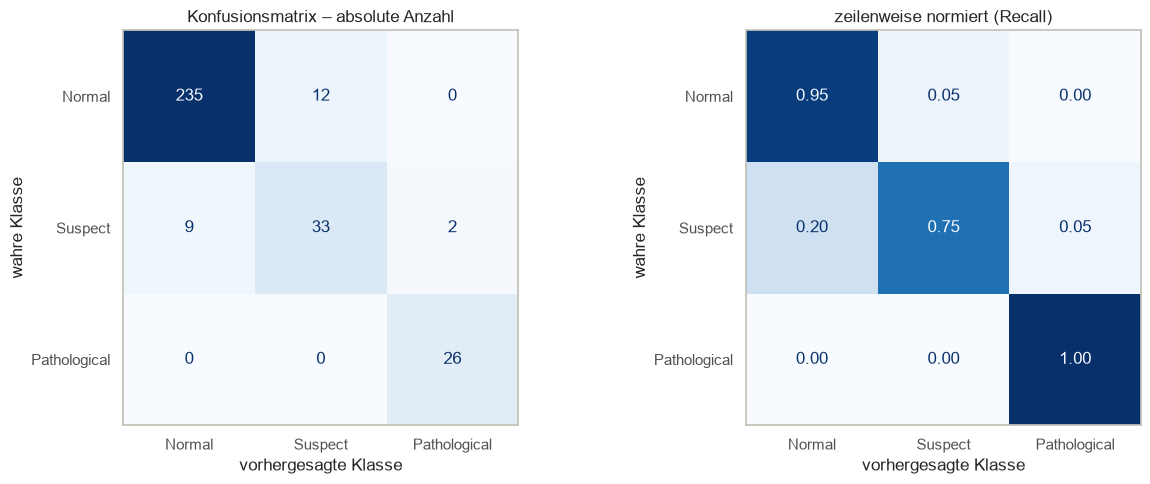

Zeilen = wahre Klasse, Spalten = Vorhersage


,pred: Normal,pred: Suspect,pred: Pathological
wahr: Normal,235,12,0
wahr: Suspect,9,33,2
wahr: Pathological,0,0,26


In [41]:
# Quelle: Claude
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

# links: absolute Zahlen | rechts: zeilenweise normiert (Diagonale = Recall je Klasse)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Konfusionsmatrix – absolute Anzahl")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=TARGET_NAMES, normalize="true",
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("zeilenweise normiert (Recall)")

for ax in axes:
    ax.set_xlabel("vorhergesagte Klasse")
    ax.set_ylabel("wahre Klasse")
    ax.grid(False)   # seaborn-Gitterlinien wuerden sonst ueber den Zellen liegen
plt.tight_layout()
plt.show()

print("Zeilen = wahre Klasse, Spalten = Vorhersage")
display(pd.DataFrame(cm, index=[f"wahr: {n}" for n in TARGET_NAMES],
                     columns=[f"pred: {n}" for n in TARGET_NAMES]))

### Interpretation der Konfusionsmatrix

|  | pred: Normal | pred: Suspect | pred: Pathological |
|---|---|---|---|
| **wahr: Normal** (247) | **235** | 12 | 0 |
| **wahr: Suspect** (44) | 9 | **33** | 2 |
| **wahr: Pathological** (26) | 0 | 0 | **26** |

**Welche Klassen werden am häufigsten miteinander verwechselt?**
Eindeutig **Normal ↔ Suspect**: 12 normale CTGs werden als Suspect eingestuft, 9 Suspect-Fälle
als Normal – zusammen 21 der 23 Fehler insgesamt. Das deckt sich genau mit der EDA aus
Schritt 1.7: Suspect liegt bei den meisten Features *zwischen* den beiden anderen Klassen
und überlappt stark mit Normal. Die Grenze „noch normal / schon verdächtig“ ist auch
klinisch ein Graubereich.

**Welche Klasse wird am schlechtesten erkannt (niedrigster Recall)?**
**Suspect** mit einem Recall von **0,750** (33 von 44). Normal liegt bei 0,951,
Pathological bei **1,000**.

**Bemerkenswert – die kritische Klasse:** Alle **26 von 26 pathologischen Fällen** werden
erkannt; die Spalte „wahr: Pathological“ enthält keinen einzigen Fehler. Ebenso wichtig:
In der Spalte „pred: Normal“ steht bei Pathological eine **0** – kein pathologischer Fall
wurde als unauffällig durchgewinkt. Das ist genau das Verhalten, auf das wir mit
`class_weight="balanced"` hingearbeitet haben.

**Was bedeutet das im Praxiskontext?**
Ein solches Modell wäre ein **Screening-/Assistenzsystem**, das CTGs zur ärztlichen Prüfung
vorsortiert. Für diesen Einsatz gilt:

- **Die 12 Fehlalarme (Normal → Suspect)** sind der günstigste Fehlertyp: Sie führen zu einer
  zusätzlichen Kontrolle durch Fachpersonal, das die Fehleinschätzung korrigiert. Kosten:
  Zeit und ggf. Verunsicherung der Patientin.
- **Die 2 Fälle Suspect → Pathological** sind Übervorsicht und damit unkritisch – sie lösen
  eine intensivere Abklärung aus, als nötig gewesen wäre.
- **Die 9 Fälle Suspect → Normal** sind der problematischste Fehler dieses Modells:
  Ein verdächtiges CTG wird als unauffällig eingestuft und fällt aus der Nachbeobachtung.
  Zwar ist „Suspect“ definitionsgemäß nicht akut bedrohlich, doch eine Verlaufskontrolle wäre
  hier medizinisch angezeigt.
- **Kein übersehener pathologischer Fall** – die teuerste Fehlklassifikation tritt im Testset
  nicht auf.

**Einschränkung bei der Interpretation:** Das Testset enthält nur 26 pathologische Fälle.
Ein Recall von 1,000 bedeutet „0 von 26 übersehen“, nicht „nie ein Fehler“ – das
95-%-Konfidenzintervall reicht hier bis etwa 0,87 hinunter. Bei so kleinen Stichproben ist
ein perfekter Wert ein gutes Zeichen, aber keine Garantie (siehe auch Schritt 7).

## 6.7 Ergänzend: classification_report

Der Report zeigt Precision, Recall und F1 **je Klasse** – also die Schwachstellen, die die
Gesamt-Accuracy von 0,927 verdeckt.

In [42]:
# Quelle: Claude
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred, target_names=TARGET_NAMES, digits=3))

              precision    recall  f1-score   support

      Normal      0.963     0.951     0.957       247
     Suspect      0.733     0.750     0.742        44
Pathological      0.929     1.000     0.963        26

    accuracy                          0.927       317
   macro avg      0.875     0.900     0.887       317
weighted avg      0.928     0.927     0.928       317



### Was der Report zeigt, das die Accuracy verbirgt

- **Accuracy 0,927 klingt einheitlich gut – ist es aber nicht.** Die Güte verteilt sich sehr
  ungleich: F1 0,957 (Normal) und 0,963 (Pathological), aber nur **0,742 (Suspect)**.
- **Suspect ist von beiden Seiten schwach:** Precision 0,733 (von 45 Suspect-Vorhersagen sind
  12 falsch) *und* Recall 0,750. Diese Klasse ist die eigentliche Schwachstelle des Modells.
- **`macro avg` (0,887) liegt deutlich unter `weighted avg` (0,928).** Der Macro-Durchschnitt
  gewichtet alle Klassen gleich und macht damit sichtbar, dass die Leistung stark von der
  großen Klasse Normal getragen wird – exakt der didaktische Punkt des Assignments.
- **Pathological ist trotz nur 26 Fällen die zweitbeste Klasse** (Precision 0,929,
  Recall 1,000). Die Klassengewichtung hat hier gewirkt: Die kleinste Klasse ist die am
  zuverlässigsten erkannte – ungewöhnlich und für den Anwendungsfall genau richtig.

## 6.8 Feature Importances des finalen Modells

Zum Abschluss prüfen wir, ob das Modell dieselben Features nutzt, die wir in Schritt 1.8 als
relevant vermutet hatten – ein Plausibilitätscheck der EDA.

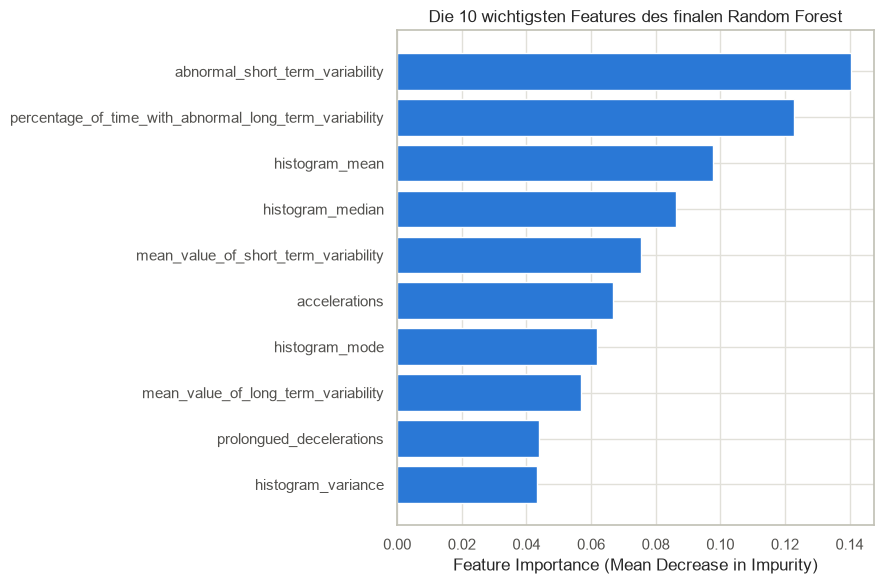

,Importance
abnormal_short_term_variability,0.1405
percentage_of_time_with_abnormal_long_term_variability,0.1229
histogram_mean,0.0976
histogram_median,0.0862
mean_value_of_short_term_variability,0.0756
accelerations,0.0668
histogram_mode,0.0617
mean_value_of_long_term_variability,0.0570
prolongued_decelerations,0.0439
histogram_variance,0.0434


In [43]:
# Quelle: Claude
importances = (pd.Series(finales_modell.feature_importances_, index=X.columns)
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
top10 = importances.head(10).iloc[::-1]
ax.barh(top10.index, top10.values, color="#2a78d6")
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Die 10 wichtigsten Features des finalen Random Forest")
plt.tight_layout()
plt.show()

display(importances.head(10).round(4).to_frame("Importance"))

### Abgleich mit der EDA-Hypothese aus Schritt 1.8

Die Übereinstimmung ist hoch – vier unserer sechs vermuteten Kandidaten stehen in den Top 6:

- `abnormal_short_term_variability` (0,141) und
  `percentage_of_time_with_abnormal_long_term_variability` (0,123) sind auch für das Modell
  die beiden wichtigsten Features – **genau wie in der EDA vermutet**.
- Die Histogramm-Lageparameter (`histogram_mean` 0,098, `histogram_median` 0,086,
  `histogram_mode` 0,062) folgen dicht dahinter. Ihre Wichtigkeit verteilt sich auf drei
  redundante Features (r ≈ 0,9 untereinander, → ADR-005) – ihr *gemeinsamer* Beitrag ist
  also größer, als jeder Einzelwert vermuten lässt.
- `accelerations` (0,067) bestätigt sich ebenfalls.

**Eine Korrektur unserer EDA-Einschätzung:** `prolongued_decelerations` hatte die *höchste*
Korrelation zur Zielvariable (r = +0,49), landet als Feature-Importance aber nur im
Mittelfeld. Der Grund: Das Feature ist in ≈ 92 % der Zeilen 0 – es ist hochspezifisch, aber
zu selten, um viele Splits zu tragen. Umgekehrt gewinnt
`mean_value_of_short_term_variability` (0,076) an Bedeutung, obwohl seine Korrelation mit
−0,10 unauffällig war: ein nichtlinearer Beitrag, den Pearson nicht sieht.

Das illustriert die Grenze der Korrelation als Vorauswahl-Heuristik – und rechtfertigt
nachträglich die Entscheidung aus ADR-005, **keine** Features anhand der Korrelation zu
entfernen.

## 6.9 Das Modell anwenden: Vorhersage für einen einzelnen Fall

Zum Abschluss schließen wir den Kreis und zeigen den **Inferenzweg**, wie er im Betrieb
aussähe: Aus den 21 CTG-Kennwerten eines einzelnen Falls entsteht eine Klassenaussage plus
Wahrscheinlichkeiten.

Hier wird auch der `LabelEncoder` aus Schritt 2.4 zum ersten Mal **rückwärts** benutzt:
`inverse_transform` übersetzt den Integer-Code des Modells zurück in den ursprünglichen Wert
der Zielvariable, den wir über `CLASS_NAMES` in einen Klarnamen abbilden. Genau diese
Rückübersetzung ist der Grund, warum wir den Encoder aufgehoben haben – ein Modell, das „2"
ausgibt, ist im klinischen Alltag unbrauchbar.

In [44]:
# Quelle: Claude
# Stellvertretend fuer einen "frisch aus dem Geraet" kommenden Fall nehmen wir eine
# Zeile des Testsets. In der Praxis kaemen die 21 Kennzahlen aus der CTG-Auswertung.
neuer_fall = X_test.iloc[[0]]          # doppelte Klammern -> DataFrame, nicht Series

code_vorhersage = finales_modell.predict(neuer_fall)[0]
wahrscheinlichkeiten = finales_modell.predict_proba(neuer_fall)[0]

# LabelEncoder rueckwaerts: Integer-Code -> Originalwert -> Klarname
original_wert = le.inverse_transform([code_vorhersage])[0]
klarname = CLASS_NAMES[original_wert]

print("Eingabe (Auszug der wichtigsten Merkmale):")
print(neuer_fall[["abnormal_short_term_variability",
                  "percentage_of_time_with_abnormal_long_term_variability",
                  "accelerations"]].to_string(index=False))

print(f"\nVorhersage: Code {code_vorhersage} "
      f"-> fetal_health = {original_wert} -> '{klarname}'")

print("\nWahrscheinlichkeiten je Klasse:")
for name, p in zip(TARGET_NAMES, wahrscheinlichkeiten):
    balken = "#" * int(round(p * 40))
    print(f"  {name:<14} {p:5.3f}  {balken}")

wahre_klasse = CLASS_NAMES[le.inverse_transform([y_test[0]])[0]]
print(f"\ntatsaechliche Klasse: '{wahre_klasse}'  -> "
      f"{'korrekt' if klarname == wahre_klasse else 'FALSCH'}")

Eingabe (Auszug der wichtigsten Merkmale):
 abnormal_short_term_variability  percentage_of_time_with_abnormal_long_term_variability  accelerations
                            76.0                                                    29.0            0.0

Vorhersage: Code 0 -> fetal_health = 1.0 -> 'Normal'

Wahrscheinlichkeiten je Klasse:
  Normal         0.730  #############################
  Suspect        0.250  ##########
  Pathological   0.020  #

tatsaechliche Klasse: 'Normal'  -> korrekt


Damit ist die Kette vollständig: **Rohe CTG-Kennzahlen → Modell → Wahrscheinlichkeiten →
Klassenname**. Für einen echten Produktiveinsatz käme genau an dieser Stelle die
Weiterverarbeitung hinzu – etwa die Anzeige der Wahrscheinlichkeiten für die befundende
Person statt nur der harten Klasse. Das entspricht unserer Empfehlung aus Schritt 7:
Das Modell liefert eine **Einschätzung mit Unsicherheitsangabe**, die ärztliche
Entscheidung bleibt beim Menschen.

---
# Schritt 7 – Reflexion und Fazit

> **Hinweis der Gruppe:** Gemäß den Regeln des Assignments zur KI-Nutzung sind
> Interpretationen, Entscheidungsbegründungen und Reflexionen eigenständig zu verfassen; die
> finale Empfehlung trifft die Gruppe. Die folgenden Abschnitte sind daher **von uns
> formuliert** und stützen sich auf die im Notebook berechneten Ergebnisse. KI-Werkzeuge
> wurden – wie an den Codezellen gekennzeichnet – für Code und als Diskussionspartner
> genutzt, nicht als Autor dieser Bewertung.

Laut Assignment sind fünf Fragen zu beantworten:

1. Welches Modell empfehlen wir für den Produktiveinsatz – und warum?
2. Was hat uns im Verlauf der Arbeit überrascht?
3. Wo sehen wir Grenzen des besten Modells im Praxiskontext?
4. Was würden wir mit mehr Zeit, mehr Daten oder mehr Ressourcen anders machen?
5. Bonusfrage: Hätte ein CNN oder Transfer Learning hier geholfen?

## 7.1 Statistische Einordnung der Testergebnisse

Bevor wir bewerten, quantifizieren wir die Unsicherheit unserer Testmetriken. Bei 317
Testsamples – davon nur 26 pathologische – sind Punktschätzer allein irreführend. Wir
berechnen daher **Wilson-Konfidenzintervalle** (95 %), die auch bei kleinen Stichproben und
Anteilen nahe 0 oder 1 verlässlich sind.

In [45]:
# Quelle: Claude
import math


def wilson_intervall(k, n, z=1.96):
    """95-%-Konfidenzintervall fuer einen Anteil k/n nach Wilson.

    Robuster als das Normal-Approximationsintervall, wenn n klein ist oder
    der Anteil nahe 0 bzw. 1 liegt (hier: Recall 26/26 = 1.0).
    """
    p = k / n
    nenner = 1 + z**2 / n
    zentrum = (p + z**2 / (2 * n)) / nenner
    spanne = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / nenner
    return max(0.0, zentrum - spanne), min(1.0, zentrum + spanne)


# Treffer je Klasse aus der Diagonale der Konfusionsmatrix
zeilen = []
for i, name in enumerate(TARGET_NAMES):
    treffer, gesamt = cm[i, i], cm[i].sum()
    lo, hi = wilson_intervall(treffer, gesamt)
    zeilen.append({"Klasse": name, "korrekt": f"{treffer}/{gesamt}",
                   "Recall": round(treffer / gesamt, 3),
                   "95-%-KI": f"[{lo:.3f}, {hi:.3f}]"})

treffer_gesamt = int(np.trace(cm))
lo, hi = wilson_intervall(treffer_gesamt, int(cm.sum()))
zeilen.append({"Klasse": "— Accuracy gesamt —", "korrekt": f"{treffer_gesamt}/{cm.sum()}",
               "Recall": round(treffer_gesamt / cm.sum(), 3),
               "95-%-KI": f"[{lo:.3f}, {hi:.3f}]"})

display(pd.DataFrame(zeilen).set_index("Klasse"))

,korrekt,Recall,95-%-KI
Klasse,,,
Normal,235/247,0.951,"[0.917, 0.972]"
Suspect,33/44,0.750,"[0.606, 0.854]"
Pathological,26/26,1.000,"[0.871, 1.000]"
— Accuracy gesamt —,294/317,0.927,"[0.893, 0.951]"


Die Intervalle zeigen deutlich, wie unterschiedlich belastbar unsere Zahlen sind:

- **Pathological:** Recall 1,000, aber das Konfidenzintervall reicht bis **0,871** hinunter.
  „26 von 26 erkannt“ ist mit einem wahren Recall von 90 % gut vereinbar – wir dürfen also
  **nicht** von einer perfekten Erkennung sprechen.
- **Suspect:** Recall 0,750 mit einem sehr breiten Intervall **[0,606; 0,854]** – bei 44
  Fällen ist selbst die Aussage „drei Viertel werden erkannt“ nur grob.
- **Accuracy gesamt:** 0,927 mit **[0,893; 0,951]** – hier ist die Schätzung am stabilsten,
  weil alle 317 Samples einfließen.

Diese Unsicherheit ziehen wir in allen folgenden Bewertungen mit.

## 7.2 Welches Modell empfehlen wir für den Produktiveinsatz – und warum?

**Unsere Empfehlung: der Random Forest mit `class_weight="balanced"`** – allerdings
ausdrücklich als **Assistenzsystem mit ärztlicher Letztentscheidung**, nicht als autonome
Diagnose.

Die Gründe, in der Reihenfolge ihres Gewichts für uns:

1. **Er ist auf der klinisch entscheidenden Klasse am stärksten.** Kein pathologischer Fall
   des Testsets wurde als „Normal“ durchgewinkt (Spalte *pred: Normal*, Zeile *Pathological*:
   0). Genau dieser Fehler wäre der einzige mit potenziell gravierenden Folgen. Alle
   Alternativmodelle übersahen 8–9 der 26 Fälle.
2. **Er ist in allen Metriken gleichzeitig vorn** – wir mussten also nicht zwischen Accuracy
   und Minderheitsklassen-Recall abwägen, was die Entscheidung robust macht.
3. **Sein Fehlerprofil passt zum Anwendungsfall.** Die verbleibenden Fehler sind überwiegend
   *vorsichtige* Fehler (12 × Normal → Suspect, 2 × Suspect → Pathological): Sie erzeugen
   Prüfaufwand, keinen Schaden.
4. **Er ist praktisch handhabbar:** Training in unter einer Sekunde, keine GPU nötig, keine
   Skalierung erforderlich (ein Vorverarbeitungsschritt weniger, der im Betrieb schiefgehen
   kann), und über Feature Importances teilweise erklärbar – in der Medizin ein reales
   Argument, weil ärztliches Personal nachvollziehen können muss, worauf ein Alarm beruht.

**Wogegen wir uns bewusst entschieden haben:** Die neuronalen Netze bringen bei diesem
Datenformat keinen Vorteil (F1w 0,886 bzw. 0,909 gegenüber 0,945), kosten aber deutlich mehr
Trainingszeit, sind schlechter erklärbar und bringen mit Keras/TensorFlow eine schwergewichtige
Abhängigkeit in den Betrieb. Für einen Produktiveinsatz ist das ein schlechtes Tauschgeschäft.

**Eine wichtige Einschränkung zu unserer eigenen Empfehlung:** Der Unterschied zwischen
Random Forest und den übrigen Modellen ist bei der Accuracy substanziell, beim
Pathological-Recall aber statistisch weniger sicher, als die Punktschätzer suggerieren –
26 Testfälle sind schlicht wenig. Wir empfehlen den Random Forest, weil er in *jeder*
Auswertung (CV, Validierung, Test) vorn lag, nicht wegen eines einzelnen Zahlenvorsprungs.

## 7.3 Was hat uns im Verlauf der Arbeit überrascht?

**1. Dass die neuronalen Netze verloren haben.** Wir waren davon ausgegangen, dass das
„modernere“ Verfahren gewinnt. Tatsächlich lag selbst die optimierte Variante B (F1w 0,909)
klar hinter einem Random Forest mit Default-Parametern (0,945). Rückblickend ist das
plausibel – 1.479 Trainingsbeispiele mit 21 vorverarbeiteten Merkmalen sind genau die
Situation, für die Baumensembles gebaut sind, während ein MLP seine Stärke (Lernen von
Repräsentationen aus rohen, hochdimensionalen Daten) hier gar nicht ausspielen kann. Die
Lehre für uns: Modellwahl folgt der Datenform, nicht der Aktualität des Verfahrens.

**2. Dass die *tiefere* Variante B zunächst schlechter war als die flache Variante A.**
Mehr Schichten plus Regularisierung klang nach einer sicheren Verbesserung – das Gegenteil
trat ein (F1w 0,877 vs. 0,886). Erst die Analyse der Lernkurven zeigte, dass nicht die
Architektur schuld war, sondern der Optimierer: Mit reinem SGD blieb das Training in einem
flachen Bereich stecken, den Early Stopping als Konvergenz missdeutete. Ein einziger
Zusatz (`momentum=0.9`) drehte das Ergebnis auf 0,909. Uns hat überrascht, wie stark der
Optimierer den Architektureffekt überlagert – und wie leicht man daraus die falsche
Schlussfolgerung „die Architektur taugt nichts“ gezogen hätte.

**3. Dass das *stärkste* Korrelations-Feature im Modell nur Mittelmaß ist.**
`prolongued_decelerations` hatte mit r = +0,49 die höchste Korrelation zur Zielvariable, landet
bei den Feature Importances aber nur auf Platz 9 – weil es in 92 % der Zeilen 0 ist und damit
zu wenige Splits trägt. Umgekehrt wurde `mean_value_of_short_term_variability` (r = −0,10,
also unauffällig) zum fünftwichtigsten Feature. Das hat uns vor Augen geführt, wie
begrenzt Pearson-Korrelation als Auswahlheuristik ist – und nachträglich unsere Entscheidung
bestätigt, keine Features vorab zu entfernen (→ ADR-005).

**4. Wie viel der `classification_report` gegenüber der Accuracy verbirgt.**
Accuracy 0,927 klingt gleichmäßig gut. Tatsächlich schwankt das F1 je Klasse zwischen 0,742
(Suspect) und 0,963 (Pathological). Ohne die klassenweise Aufschlüsselung hätten wir die
eigentliche Schwachstelle des Modells überhaupt nicht bemerkt.

## 7.4 Wo sehen wir Grenzen des besten Modells im Praxiskontext?

**a) Die Klasse Suspect ist die eigentliche Schwachstelle.**
Mit Recall 0,750 und Precision 0,733 ist sie von beiden Seiten unzuverlässig – und ausgerechnet
sie ist klinisch am ehesten handlungsleitend („beobachten oder nicht?“). 9 von 44
Suspect-Fällen werden als unauffällig eingestuft und fielen damit aus der Nachbeobachtung.
Wir halten das für die wichtigste offene Baustelle. Fachlich ist die Ursache nachvollziehbar:
Suspect ist definitionsgemäß der Graubereich zwischen normal und pathologisch, und schon die
EDA (Schritt 1.7) zeigte starke Überlappung mit beiden Nachbarklassen.

**b) Die Datenbasis ist für belastbare Aussagen zur kritischen Klasse zu klein.**
26 pathologische Testfälle erlauben kein Qualitätsversprechen (KI bis 0,871 hinunter, s. 7.1).
Für einen echten klinischen Einsatz wäre das keine ausreichende Evidenzbasis.

**c) Keine Aussage zur Übertragbarkeit auf andere Kliniken.**
Alle Daten stammen aus einer Quelle und wurden nach einem einheitlichen Verfahren gelabelt.
Ob das Modell auf CTG-Geräten anderer Hersteller, bei anderen Patientinnenpopulationen oder
bei abweichender Befundungspraxis ähnlich funktioniert, ist ungeprüft. Erfahrungsgemäß
brechen medizinische ML-Modelle genau an dieser Stelle ein (*Distribution Shift*).

**d) Das Modell lernt Befundungsverhalten, nicht den fetalen Zustand.**
Die Labels sind ärztliche Einschätzungen des CTG – nicht der tatsächliche Ausgang der
Geburt. Das Modell reproduziert damit bestenfalls die Urteilsqualität der Befundenden,
einschließlich deren systematischer Fehler. Ein Modell mit „perfektem“ Recall hätte gelernt,
Ärzt:innen zu imitieren – nicht, Kindern zu helfen. Für eine Aussage über den klinischen
Nutzen bräuchte man Outcome-Daten (Apgar-Score, Nabelschnur-pH), die hier nicht vorliegen.

**e) Keine Kalibrierung und kein Zeitbezug.**
Wir haben nur harte Klassenzuweisungen bewertet. Für den Betrieb wäre wichtig, ob die
Wahrscheinlichkeiten (`predict_proba`) kalibriert sind, damit man Schwellen fachlich setzen
kann. Außerdem beschreibt jede Zeile ein *aggregiertes* CTG – der zeitliche Verlauf, den
Ärzt:innen tatsächlich beurteilen, ist in den Merkmalen bereits weggerechnet.

**f) Verantwortungs- und Regulierungsfragen.**
Ein solches System wäre ein Medizinprodukt und unterläge entsprechenden Zulassungs- und
Dokumentationspflichten. Zudem besteht die Gefahr des *Automation Bias*: dass ein grünes
Modellergebnis die eigene kritische Prüfung ersetzt. Beides spricht dafür, das Modell
strikt als Zweitmeinung zu positionieren.

## 7.5 Was würden wir mit mehr Zeit, mehr Daten oder mehr Ressourcen anders machen?

**Mit mehr Daten** (unser wichtigster Hebel):

Bevor wir „mehr Daten" fordern, prüfen wir empirisch, ob mehr *Trainings*daten das Modell
überhaupt besser machen würden. Dazu dient sklearns `learning_curve`: Sie trainiert dasselbe
Modell wiederholt auf wachsenden Teilmengen und misst jeweils per Kreuzvalidierung.

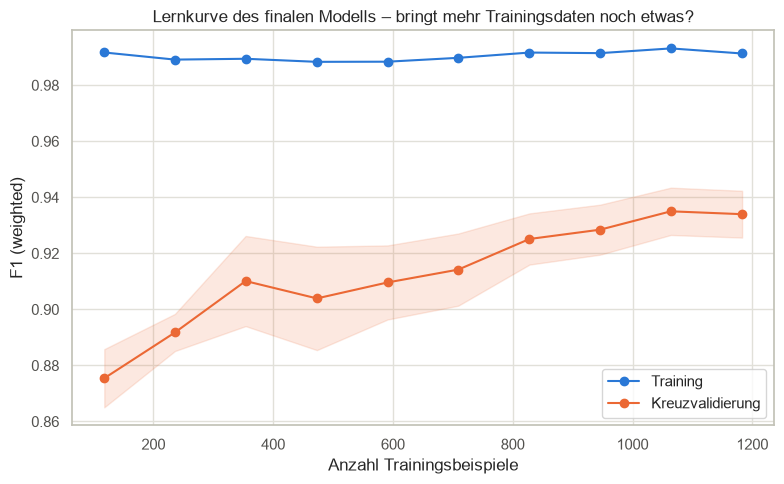

F1w bei  118 Beispielen: 0.8754
F1w bei 1183 Beispielen: 0.9340
Zuwachs insgesamt:            +0.0585
Zuwachs durch die letzten 30 % der Daten: +0.0088
typische CV-Streuung (Std):   ±0.0084


In [46]:
# Quelle: Claude
from sklearn.model_selection import learning_curve

groessen, train_scores, cv_scores = learning_curve(
    RandomForestClassifier(random_state=RANDOM_STATE, **finale_parameter),
    X_train, y_train, cv=cv, scoring="f1_weighted",
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, random_state=RANDOM_STATE)

cv_mittel, cv_std = cv_scores.mean(axis=1), cv_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(groessen, train_scores.mean(axis=1), marker="o", color="#2a78d6", label="Training")
ax.plot(groessen, cv_mittel, marker="o", color="#eb6834", label="Kreuzvalidierung")
ax.fill_between(groessen, cv_mittel - cv_std, cv_mittel + cv_std, color="#eb6834", alpha=0.15)
ax.set_xlabel("Anzahl Trainingsbeispiele")
ax.set_ylabel("F1 (weighted)")
ax.set_title("Lernkurve des finalen Modells – bringt mehr Trainingsdaten noch etwas?")
ax.legend()
plt.tight_layout()
plt.show()

print(f"F1w bei {groessen[0]:>4} Beispielen: {cv_mittel[0]:.4f}")
print(f"F1w bei {groessen[-1]:>4} Beispielen: {cv_mittel[-1]:.4f}")
print(f"Zuwachs insgesamt:            {cv_mittel[-1] - cv_mittel[0]:+.4f}")
print(f"Zuwachs durch die letzten 30 % der Daten: {cv_mittel[-1] - cv_mittel[-4]:+.4f}")
print(f"typische CV-Streuung (Std):   ±{cv_std[-1]:.4f}")

**Was die Lernkurve zeigt:** Von 118 auf 1.183 Trainingsbeispiele steigt der F1w deutlich
(+0,059). Die letzten 30 % der Daten bringen aber nur noch **+0,009** – das liegt in derselben
Größenordnung wie die CV-Streuung von ±0,008 und ist damit kaum von Rauschen zu unterscheiden.
Die Kurve ist also **stark abgeflacht, aber noch nicht vollständig im Plateau**.

Daraus folgt eine differenzierte Antwort, die wir vorher so nicht hatten:

- Mehr Trainingsdaten würden die **Modellqualität** nur noch **geringfügig** verbessern –
  vermutlich im Bereich weniger Zehntel-Prozentpunkte.
- Der Trainings-Score liegt über alle Größen hinweg bei ~0,99: Der Random Forest lernt die
  Trainingsdaten unabhängig von ihrer Menge auswendig (vgl. 6.2). Die Lücke zur
  CV-Kurve schließt sich nur langsam.
- Der eigentliche Gewinn von mehr Daten läge also **nicht** in einem besseren Modell, sondern
  in einer **belastbareren Messung** – und in mehr Fällen der kleinen Klassen, an denen
  jede Aussage derzeit hängt.

Für die Messgenauigkeit haben wir überschlagen, wie viele pathologische Fälle das Testset
bräuchte:

| gewünschte Präzision | benötigte Pathological-Fälle im Testset | entspricht Gesamtdatensatz |
|---|---|---|
| ± 10 Prozentpunkte | ca. 19 | ca. 1.500 Samples (heute erfüllt) |
| ± 5 Prozentpunkte | ca. 73 | ca. 5.900 Samples |
| ± 3 Prozentpunkte | ca. 203 | ca. 16.300 Samples |

*(Normal-Approximation bei p = 0,95, 95-%-Niveau, 8,3 % Klassenanteil, 15 % Testanteil.)*
Wir bräuchten also grob das **Dreifache** der heutigen Datenmenge für halbwegs belastbare
Aussagen – und Daten aus **mehreren Kliniken**, um Übertragbarkeit überhaupt prüfen zu können.

**Mit mehr Zeit** (methodische Verbesserungen, nach erwartetem Nutzen sortiert):

1. **Wiederholte / geschachtelte Kreuzvalidierung.** Unsere Modellauswahl beruht auf einem
   einzigen Split. Eine `RepeatedStratifiedKFold`-Auswertung würde zeigen, wie stabil der
   Vorsprung des Random Forest wirklich ist; *Nested CV* würde zusätzlich die
   Optimismus-Verzerrung durch die Hyperparameter-Suche beseitigen.
2. **Schwellenwert nach fachlichen Fehlerkosten setzen.** Die Analyse haben wir in
   Abschnitt 6.3 bereits durchgeführt und uns bewusst *gegen* eine Verschiebung entschieden,
   weil der Gewinn bei 26 Validierungsfällen im Rauschen liegt (→ ADR-016). Mit einer
   belastbaren Kostenangabe („ein übersehener Fall entspricht X Fehlalarmen") und mehr Fällen
   ließe sich der Arbeitspunkt dagegen sauber optimieren – aus unserer Sicht der Hebel mit dem
   besten Verhältnis von Aufwand zu klinischem Nutzen.
3. **Gezielte Arbeit an der Klasse Suspect** – z. B. ein zweistufiges Vorgehen: erst
   „unauffällig vs. auffällig“, dann innerhalb der auffälligen Fälle differenzieren.
4. **Modellkalibrierung** prüfen und ggf. mit `CalibratedClassifierCV` korrigieren.
5. **XGBoost / LightGBM** als Alternative testen – bei tabellarischen Daten häufig noch etwas
   stärker als ein Random Forest, was wir aus Zeit- und Abhängigkeitsgründen nicht getan haben.
6. **Erklärbarkeit vertiefen:** Feature Importances sind global; SHAP-Werte würden pro
   Einzelfall zeigen, *warum* ein CTG als pathologisch gilt – für die ärztliche Akzeptanz
   vermutlich wichtiger als ein weiterer Prozentpunkt Accuracy.

**Mit mehr Ressourcen:** Rechenleistung war hier ausdrücklich **nicht** der Engpass – der
gesamte GridSearch lief in unter 10 Sekunden. Zusätzliche GPU-Kapazität würde an unserem
Ergebnis nichts ändern. Der Engpass ist die Datenmenge und die fachliche Validierung, nicht
die Hardware. Das war für uns eine der nützlichsten Erkenntnisse des Projekts.

## 7.6 Bonusfrage: Hätte ein CNN oder Transfer Learning hier geholfen?

**Auf unseren Daten: nein – und zwar aus einem strukturellen Grund.**

Ein CNN nutzt aus, dass benachbarte Eingabewerte **räumlich oder zeitlich zusammenhängen**:
Bei einem Bild sind benachbarte Pixel Teil derselben Kante, bei einem Zeitsignal benachbarte
Messpunkte Teil desselben Verlaufs. Genau diese Nachbarschaft existiert in unseren Daten
nicht. Unsere 21 Spalten sind eine **ungeordnete Menge** aggregierter Kennzahlen – man könnte
`histogram_width` und `accelerations` vertauschen, ohne dass sich inhaltlich etwas ändert.
Ein Faltungskern über diese Spalten würde Nachbarschaften auswerten, die es gar nicht gibt.

Auch **Transfer Learning** hilft hier nicht: Vortrainierte Netze (ImageNet, Sprachmodelle)
haben Repräsentationen für Bilder oder Text gelernt. Für 21 CTG-Kennzahlen gibt es kein
sinnvolles vortrainiertes Modell, dessen Merkmalsraum zu unserem passt.

**Wo beides sehr wohl helfen könnte – auf anderen Daten:**

Der entscheidende Punkt ist, dass unsere Merkmale bereits das Ergebnis einer Vorverarbeitung
sind: Aus dem ursprünglichen CTG-Zeitsignal (Herzfrequenz und Wehen über Minuten hinweg)
wurden von Menschen definierte Kennzahlen berechnet. **Auf dem rohen Zeitsignal** wäre ein
1D-CNN die naheliegende Architektur – es könnte Muster lernen, die in keiner der 21 Kennzahlen
abgebildet sind, etwa die zeitliche Kopplung zwischen einer Wehe und der darauf folgenden
Dezeleration (klinisch der Unterschied zwischen frühen und späten Dezelerationen, der für die
Beurteilung zentral ist). Diese Information ist in unserem aggregierten Datensatz
**unwiederbringlich verloren**.

Ebenso wäre Transfer Learning dort denkbar: ein auf großen Mengen unbeschrifteter
CTG-Aufzeichnungen selbstüberwacht vortrainiertes Modell, das anschließend auf die
kleine gelabelte Menge feinabgestimmt wird – ein plausibler Weg, das Problem der nur
175 pathologischen Fälle zu entschärfen.

**Unser Fazit zur Bonusfrage:** Nicht das Verfahren entscheidet, sondern die Datenform. Für
tabellarische, aggregierte Merkmale in dieser Größenordnung sind Baumensembles die
angemessene Wahl – Deep Learning würde erst dann interessant, wenn wir eine Ebene tiefer
gingen und mit den Rohsignalen arbeiteten.

## 7.7 Gesamtfazit

Wir haben fünf Modelle nach einem einheitlichen, leakage-freien Protokoll verglichen:
Duplikate vor dem Split entfernt, stratifiziert 70/15/15 geteilt, den Scaler ausschließlich
auf den Trainingsdaten gefittet, alle Modellentscheidungen über Kreuzvalidierung und
Validierungsset getroffen und das Testset genau einmal angefasst.

**Ergebnis:** Ein Random Forest mit ausgeglichenen Klassengewichten erreicht auf dem Testset
**Accuracy 0,927 und F1 (weighted) 0,928** und erkennt alle 26 pathologischen Fälle. Er
schlägt beide neuronalen Netze deutlich.

**Was wir methodisch mitnehmen:** Die wichtigsten Erkenntnisse des Projekts kamen nicht aus
der besten Zahl, sondern aus dem genauen Hinsehen – die Konfusionsmatrix zeigte die
Schwäche bei *Suspect*, die die Accuracy verdeckte; die Lernkurven zeigten, dass Variante B
am Optimierer scheiterte und nicht an der Architektur; die Feature Importances korrigierten
unsere Korrelations-Hypothese aus der EDA. Und die Konfidenzintervalle machten deutlich, dass
unser bestes Einzelergebnis – ein Recall von 1,000 – die am wenigsten belastbare Zahl des
gesamten Projekts ist.

Für einen realen Einsatz wäre dieses Modell ein **Kandidat für eine Assistenzfunktion mit
ärztlicher Letztentscheidung**, kein fertiges Diagnosewerkzeug. Der Weg dorthin führt über
mehr Daten aus mehreren Kliniken und über eine Validierung an tatsächlichen
Geburtsausgängen – nicht über ein größeres Modell.